## 高遠球程式(新)

**用途**：訓練高遠球的 pretrained LSTM 模型（model1~model5）

**輸入**：`./data/grade_and_comment_separate.json`

**輸出**：`models/model1.keras` ~ `models/model5.keras`
（⚠️ 這是目前 fine-tune 實驗實際在用的模型來源，不要刪）

**狀態**：✅ 使用中 / 目前的正式版本

**備註**：後半段（model6~model10）是另外嘗試的 transfer learning 實驗，存成 `.h5`，目前 fine-tune pipeline 沒有在用這批。

**更新日期**：2026-08-15

In [62]:
import json
import numpy as np
import pandas as pd

# 載入資料

In [63]:
with open('./data/grade_and_comment_separate.json', 'r', encoding='utf-8') as file:
    data = json.load(file)
df = pd.DataFrame(data)
display(df)

,檔名,評語,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,h001_44333_1,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.124, 4.53, 4.132, 4.308, 4.462, 5.16, 5.94,...","[3.692, 5.22, 5.966, 5.586, 4.494, 3.394, 3.37...","[4.186, 3.448, 1.836, 1.03, 1.162, 1.626, 2.55...","[-1.906, -1.442, -0.992, -0.414, -0.468, -1.36...","[-1.14, -0.952, -0.794, -0.626, -0.598, -1.134...","[-0.04, -0.048, -0.19, -0.352, -0.332, 0.002, ..."
1,h001_44333_10,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.328, 5.19, 5.226, 5.446, 5.74, 5.954, 5.922...","[7.996, 8.284, 8.554, 8.426, 8.136, 7.914, 8.1...","[0.446, 0.442, 0.404, -0.358, -1.192, -1.29, -...","[-0.386, -0.218, -0.09, 0.182, 0.25, -0.172, -...","[-1.212, -1.264, -1.19, -0.968, -0.708, -0.666...","[0.512, 0.674, 0.766, 0.684, 0.592, 0.582, 0.6..."
2,h001_44333_11,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[2.642, 3.136, 4.28, 5.506, 5.918, 6.172, 5.74...","[6.086, 7.234, 8.492, 9.034, 8.772, 8.822, 8.9...","[2.45, 1.482, 1.194, 1.724, 1.128, 1.738, 2.41...","[-2.606, -2.326, -1.872, -1.804, -1.896, -1.85...","[-1.67, -1.578, -1.64, -1.724, -1.684, -1.612,...","[0.632, 0.52, 0.268, 0.122, 0.158, 0.23, 0.234..."
3,h001_44333_12,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[6.69, 6.928, 6.838, 6.484, 6.148, 6.188, 6.80...","[5.562, 6.346, 8.194, 10.77, 12.856, 13.026, 1...","[2.224, 3.058, 3.69, 3.882, 2.536, 1.508, 1.45...","[-3.788, -4.3, -4.564, -4.25, -3.094, -1.502, ...","[-1.134, -0.91, -0.726, -0.762, -0.76, -0.836,...","[-1.09, -1.522, -1.74, -1.678, -1.508, -1.566,..."
4,h001_44333_13,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.91, 6.052, 6.232, 6.458, 6.282, 6.014, 6.29...","[7.586, 7.048, 7.172, 7.59, 8.362, 9.42, 9.702...","[2.576, 2.534, 2.478, 2.844, 2.922, 2.086, 1.5...","[-1.93, -2.22, -2.438, -2.568, -2.484, -2.048,...","[-1.386, -1.38, -1.382, -1.384, -1.514, -1.486...","[-0.042, -0.198, -0.262, -0.22, -0.052, 0.268,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5904,h203_55555_5,標準,2,2,2,2,2,"[0.19, 0.638, 1.412, 2.292, 2.768, 3.526, 4.30...","[-0.912, -0.208, 1.534, 2.556, 2.876, 2.162, 1...","[2.758, 2.382, 2.258, 2.31, 2.746, 2.63, 2.62,...","[-3.504, -3.808, -4.004, -4.08, -4.084, -3.826...","[-1.596, -1.502, -1.448, -1.43, -1.422, -1.438...","[0.172, 0.032, -0.064, -0.148, -0.252, -0.282,..."
5905,h203_55555_6,標準,2,2,2,2,2,"[-8.946, -6.948, -4.988, -3.088, -1.666, -0.46...","[4.028, 1.77, -0.026, -0.354, 1.132, 4.114, 6....","[2.574, 0.678, -1.17, -1.816, -1.648, -1.192, ...","[-3.03, -2.768, -3.268, -4.174, -4.81, -4.76, ...","[-2.236, -1.95, -1.698, -1.498, -1.344, -1.254...","[-0.32, -0.386, -0.446, -0.578, -0.75, -0.888,..."
5906,h203_55555_7,標準,2,2,2,2,2,"[-5.296, -5.0, -5.332, -5.382, -5.012, -4.358,...","[7.06, 7.764, 8.554, 7.668, 5.266, 3.426, 3.08...","[9.18, 8.266, 7.968, 7.44, 6.782, 5.248, 3.05,...","[-4.87, -4.754, -4.276, -3.866, -3.716, -3.988...","[-4.084, -3.986, -3.88, -3.692, -3.472, -3.274...","[0.666, 0.372, 0.174, 0.054, -0.03, -0.156, -0..."
5907,h203_55555_8,標準,2,2,2,2,2,"[-2.82, -1.68, -0.336, 1.03, 2.004, 3.51, 5.03...","[1.808, 2.078, 3.22, 3.094, 1.974, 1.264, 1.36...","[-2.354, -3.094, -3.398, -3.714, -4.498, -4.96...","[-3.972, -4.036, -3.906, -3.686, -3.566, -3.50...","[-1.26, -0.96, -0.732, -0.516, -0.318, -0.138,...","[-0.78, -0.842, -0.914, -0.872, -0.862, -0.868..."


In [64]:
# define parameter
sample_count = len(data)
swing_time = 125 #1.25s
score_category_count = 3 #0,1,2

# 應變數

In [65]:
y1 = df['揮拍軌跡正確度'].values.astype(int)
y2 = df['揮拍速度流暢度'].values.astype(int)
y3 = df['手腕轉動時機正確度'].values.astype(int)
y4 = df['擊球時機正確度'].values.astype(int)
y5 = df['擊球位置正確度'].values.astype(int)

In [66]:
Y = [y1, y2, y3, y4, y5]

# 決定20%訓練集

In [67]:
low_file = []
mid_file = []
high_file = []
test_file = []
val_file = []
train_file = []

In [68]:
overall_high_file = []
overall_mid_file = []
overall_low_file = []
avg_list = []
for i in range(sample_count):
    avg = (y1[i] + y2[i] + y3[i] + y4[i] + y5[i])/5
    if avg == 2:
        overall_high_file.append(df['檔名'][i].split('_')[0])
    elif avg < 2 and avg > 0.7:
        overall_mid_file.append(df['檔名'][i].split('_')[0])
    else:
        overall_low_file.append(df['檔名'][i].split('_')[0])

overall_high_file = list(set(overall_high_file))
overall_mid_file = list(set(overall_mid_file))
overall_low_file = list(set(overall_low_file))
print(overall_high_file)
print(overall_mid_file)
print(overall_low_file)

['h162', 'h067', 'h173', 'h014', 'h077', 'h126', 'h155', 'h194', 'h020', 'h015', 'h156', 'h035', 'h073', 'h117', 'h187', 'h191', 'h125', 'h055', 'h203', 'h103', 'h024', 'h196', 'h152', 'h124', 'h133', 'h057', 'h006', 'h151', 'h085', 'h005', 'h047', 'h144', 'h115', 'h198', 'h104', 'h064', 'h042', 'h158', 'h174', 'h081', 'h190']
['h003', 'h109', 'h165', 'h089', 'h007', 'h032', 'h040', 'h181', 'h063', 'h060', 'h061', 'h079', 'h069', 'h138', 'h140', 'h157', 'h197', 'h149', 'h052', 'h016', 'h150', 'h029', 'h179', 'h099', 'h010', 'h195', 'h058', 'h086', 'h136', 'h068', 'h129', 'h192', 'h072', 'h199', 'h082', 'h188', 'h200', 'h037', 'h185', 'h193', 'h177', 'h122', 'h074', 'h013', 'h145', 'h078', 'h166', 'h041', 'h022', 'h148', 'h130', 'h160', 'h176', 'h001', 'h147', 'h088', 'h076', 'h175', 'h189', 'h033', 'h021', 'h186', 'h142', 'h087', 'h036', 'h002', 'h132', 'h025', 'h128', 'h202', 'h028', 'h062', 'h017', 'h053', 'h201', 'h031', 'h065', 'h161', 'h167', 'h139', 'h030', 'h011', 'h054', 'h168'

In [69]:
from sklearn.model_selection import train_test_split
import numpy as np

# ***** 設置固定的隨機種子 *****
FIXED_RANDOM_STATE = 5

# 初始化最終的訓練集和測試集檔案名稱列表
overall_train_file = []
overall_test_file = []

print("=== 檔案整體隨機分層切分開始 ===")
# 假設 overall_high_file, overall_mid_file, overall_low_file 已經定義
print(f"原始總高分檔案數: {len(overall_high_file)}")
print(f"原始總中分檔案數: {len(overall_mid_file)}")
print(f"原始總低分檔案數: {len(overall_low_file)}")
print("-" * 30)

# --- 1. 對高分檔案進行 80/20 切分 ---
if overall_high_file:
    high_train, high_test = train_test_split(
        overall_high_file,
        test_size=0.2, 
        # ***** 關鍵修正：加入 random_state *****
        random_state=FIXED_RANDOM_STATE 
        # shuffle=True 預設就是 True，且在設置 random_state 後，打亂結果會固定
    )
    overall_train_file.extend(high_train)
    overall_test_file.extend(high_test)
    print(f"高分組：訓練 {len(high_train)} 個, 測試 {len(high_test)} 個")
else:
    print("高分組檔案列表為空，未進行切分。")


# --- 2. 對中分檔案進行 80/20 切分 ---
if overall_mid_file:
    mid_train, mid_test = train_test_split(
        overall_mid_file,
        test_size=0.2,
        # ***** 關鍵修正：加入 random_state *****
        random_state=FIXED_RANDOM_STATE
    )
    overall_train_file.extend(mid_train)
    overall_test_file.extend(mid_test)
    print(f"中分組：訓練 {len(mid_train)} 個, 測試 {len(mid_test)} 個")
else:
    print("中分組檔案列表為空，未進行切分。")


# --- 3. 對低分檔案進行 80/20 切分 ---
if overall_low_file:
    low_train, low_test = train_test_split(
        overall_low_file,
        test_size=0.2,
        # ***** 關鍵修正：加入 random_state *****
        random_state=FIXED_RANDOM_STATE
    )
    overall_train_file.extend(low_train)
    overall_test_file.extend(low_test)
    print(f"低分組：訓練 {len(low_train)} 個, 測試 {len(low_test)} 個")
else:
    print("低分組檔案列表為空，未進行切分。")

print("-" * 30)
print("✅ 整體檔案名稱切分完成！")
print(f"總訓練集檔案數 (overall_train_file): {len(overall_train_file)}")
print(f"總測試集檔案數 (overall_test_file): {len(overall_test_file)}")
print(f"總檔案數 (總和): {len(overall_train_file) + len(overall_test_file)}")

=== 檔案整體隨機分層切分開始 ===
原始總高分檔案數: 41
原始總中分檔案數: 92
原始總低分檔案數: 68
------------------------------
高分組：訓練 32 個, 測試 9 個
中分組：訓練 73 個, 測試 19 個
低分組：訓練 54 個, 測試 14 個
------------------------------
✅ 整體檔案名稱切分完成！
總訓練集檔案數 (overall_train_file): 159
總測試集檔案數 (overall_test_file): 42
總檔案數 (總和): 201


In [70]:
import numpy as np
import pandas as pd # 確保已載入

# 假設 df 是您的原始數據，並且 overall_test_file 已經定義

# --- 1. 根據檔案名稱，切分出 X 的訓練/驗證數據和測試數據 ---

# 切分 DataFrame
df_train = df[df['檔名'].apply(lambda x: x.split('_')[0]).isin(overall_train_file)].copy()
df_test = df[df['檔名'].apply(lambda x: x.split('_')[0]).isin(overall_test_file)].copy()


# 提醒：如果您在前面的 train/val 切分中決定了最終的 train_indices 和 val_indices，
# 您也可以使用這些索引來切分 df_train 和 df_val。
# 但對於 X 的標準化，我們通常只需要區分：Train+Val vs Test。

In [71]:


# ***** 關鍵步驟 *****
# 重設索引，並丟棄原有的行號 (drop=True)
print(df_train.index.tolist()[-1])
print(df_test.index.tolist()[-1])
df_train = df_train.reset_index(drop=True) 

# 此時，df_train 的索引就是 0, 1, 2, ..., 4677
# 假設 df 是您的原始完整 DataFrame
print("--- df_train 處理完成 ---")
print(f"df_train 的樣本總數 (rows): {len(df_train)}")
print(f"df_train 的新索引範圍為 0 到 {len(df_train) - 1}。")
# 假設 overall_test_file 是 20% 檔案名稱列表

# 1. 篩選出 20% 的數據
df_test = df[df['檔名'].apply(lambda x: x.split('_')[0]).isin(set(overall_test_file))]

# ***** 關鍵步驟 *****
# 2. 重設索引，並丟棄原有的行號 (drop=True)
df_test = df_test.reset_index(drop=True) 

# 輸出檢查
print("--- df_test 處理完成 ---")
print(f"df_test 的樣本總數 (rows): {len(df_test)}")
print(f"df_test 的新索引範圍為 0 到 {len(df_test) - 1}。")

5908
5848
--- df_train 處理完成 ---
df_train 的樣本總數 (rows): 4659
df_train 的新索引範圍為 0 到 4658。
--- df_test 處理完成 ---
df_test 的樣本總數 (rows): 1250
df_test 的新索引範圍為 0 到 1249。


In [72]:
display(df_train)

,檔名,評語,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,h001_44333_1,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.124, 4.53, 4.132, 4.308, 4.462, 5.16, 5.94,...","[3.692, 5.22, 5.966, 5.586, 4.494, 3.394, 3.37...","[4.186, 3.448, 1.836, 1.03, 1.162, 1.626, 2.55...","[-1.906, -1.442, -0.992, -0.414, -0.468, -1.36...","[-1.14, -0.952, -0.794, -0.626, -0.598, -1.134...","[-0.04, -0.048, -0.19, -0.352, -0.332, 0.002, ..."
1,h001_44333_10,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.328, 5.19, 5.226, 5.446, 5.74, 5.954, 5.922...","[7.996, 8.284, 8.554, 8.426, 8.136, 7.914, 8.1...","[0.446, 0.442, 0.404, -0.358, -1.192, -1.29, -...","[-0.386, -0.218, -0.09, 0.182, 0.25, -0.172, -...","[-1.212, -1.264, -1.19, -0.968, -0.708, -0.666...","[0.512, 0.674, 0.766, 0.684, 0.592, 0.582, 0.6..."
2,h001_44333_11,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[2.642, 3.136, 4.28, 5.506, 5.918, 6.172, 5.74...","[6.086, 7.234, 8.492, 9.034, 8.772, 8.822, 8.9...","[2.45, 1.482, 1.194, 1.724, 1.128, 1.738, 2.41...","[-2.606, -2.326, -1.872, -1.804, -1.896, -1.85...","[-1.67, -1.578, -1.64, -1.724, -1.684, -1.612,...","[0.632, 0.52, 0.268, 0.122, 0.158, 0.23, 0.234..."
3,h001_44333_12,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[6.69, 6.928, 6.838, 6.484, 6.148, 6.188, 6.80...","[5.562, 6.346, 8.194, 10.77, 12.856, 13.026, 1...","[2.224, 3.058, 3.69, 3.882, 2.536, 1.508, 1.45...","[-3.788, -4.3, -4.564, -4.25, -3.094, -1.502, ...","[-1.134, -0.91, -0.726, -0.762, -0.76, -0.836,...","[-1.09, -1.522, -1.74, -1.678, -1.508, -1.566,..."
4,h001_44333_13,"擊球時手腕使用較少,每拍擊球時機點及擊球位置可再一致",1,1,1,1,1,"[5.91, 6.052, 6.232, 6.458, 6.282, 6.014, 6.29...","[7.586, 7.048, 7.172, 7.59, 8.362, 9.42, 9.702...","[2.576, 2.534, 2.478, 2.844, 2.922, 2.086, 1.5...","[-1.93, -2.22, -2.438, -2.568, -2.484, -2.048,...","[-1.386, -1.38, -1.382, -1.384, -1.514, -1.486...","[-0.042, -0.198, -0.262, -0.22, -0.052, 0.268,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4654,h203_55555_5,標準,2,2,2,2,2,"[0.19, 0.638, 1.412, 2.292, 2.768, 3.526, 4.30...","[-0.912, -0.208, 1.534, 2.556, 2.876, 2.162, 1...","[2.758, 2.382, 2.258, 2.31, 2.746, 2.63, 2.62,...","[-3.504, -3.808, -4.004, -4.08, -4.084, -3.826...","[-1.596, -1.502, -1.448, -1.43, -1.422, -1.438...","[0.172, 0.032, -0.064, -0.148, -0.252, -0.282,..."
4655,h203_55555_6,標準,2,2,2,2,2,"[-8.946, -6.948, -4.988, -3.088, -1.666, -0.46...","[4.028, 1.77, -0.026, -0.354, 1.132, 4.114, 6....","[2.574, 0.678, -1.17, -1.816, -1.648, -1.192, ...","[-3.03, -2.768, -3.268, -4.174, -4.81, -4.76, ...","[-2.236, -1.95, -1.698, -1.498, -1.344, -1.254...","[-0.32, -0.386, -0.446, -0.578, -0.75, -0.888,..."
4656,h203_55555_7,標準,2,2,2,2,2,"[-5.296, -5.0, -5.332, -5.382, -5.012, -4.358,...","[7.06, 7.764, 8.554, 7.668, 5.266, 3.426, 3.08...","[9.18, 8.266, 7.968, 7.44, 6.782, 5.248, 3.05,...","[-4.87, -4.754, -4.276, -3.866, -3.716, -3.988...","[-4.084, -3.986, -3.88, -3.692, -3.472, -3.274...","[0.666, 0.372, 0.174, 0.054, -0.03, -0.156, -0..."
4657,h203_55555_8,標準,2,2,2,2,2,"[-2.82, -1.68, -0.336, 1.03, 2.004, 3.51, 5.03...","[1.808, 2.078, 3.22, 3.094, 1.974, 1.264, 1.36...","[-2.354, -3.094, -3.398, -3.714, -4.498, -4.96...","[-3.972, -4.036, -3.906, -3.686, -3.566, -3.50...","[-1.26, -0.96, -0.732, -0.516, -0.318, -0.138,...","[-0.78, -0.842, -0.914, -0.872, -0.862, -0.868..."


In [73]:
display(df_test)

,檔名,評語,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,h010_44133_1,擊球時未使用手腕，擊球位置不正確,1,1,0,1,1,"[3.706, 3.398, 3.178, 2.946, 2.77, 2.716, 2.66...","[6.022, 6.216, 6.502, 6.56, 6.45, 6.322, 6.018...","[8.104, 8.142, 8.038, 7.832, 7.598, 7.306, 7.5...","[-1.224, -1.334, -1.462, -1.39, -1.206, -1.268...","[-2.724, -2.8, -2.814, -2.768, -2.702, -2.622,...","[2.004, 1.952, 1.872, 1.662, 1.506, 1.41, 1.16..."
1,h010_44133_10,擊球時未使用手腕，擊球位置不正確,1,1,0,1,1,"[7.442, 7.67, 7.374, 6.714, 6.404, 6.302, 6.12...","[1.296, 1.304, 1.252, 1.43, 1.616, 1.382, 1.21...","[-0.708, -0.534, -0.35, -0.748, -1.138, -0.834...","[-1.24, -1.132, -1.192, -1.368, -1.462, -1.39,...","[-3.244, -3.242, -3.146, -2.972, -2.79, -2.62,...","[-0.002, -0.03, 0.012, 0.1, 0.208, 0.296, 0.36..."
2,h010_44133_11,擊球時未使用手腕，擊球位置不正確,1,1,0,1,1,"[8.736, 9.398, 8.984, 7.612, 6.522, 5.792, 5.2...","[-1.352, 0.098, 1.192, 1.224, 0.338, -0.33, -0...","[-7.196, -6.736, -6.308, -5.99, -5.838, -5.668...","[-0.9, -0.92, -0.92, -0.992, -1.232, -1.53, -1...","[-1.89, -1.746, -1.662, -1.626, -1.55, -1.436,...","[-0.038, -0.07, -0.058, -0.054, -0.068, -0.092..."
3,h010_44133_12,擊球時未使用手腕，擊球位置不正確,1,1,0,1,1,"[-2.124, -1.916, -1.612, -1.384, -1.1, -0.856,...","[9.768, 9.25, 8.858, 8.808, 8.974, 9.06, 9.076...","[-5.732, -5.08, -4.63, -4.524, -4.594, -4.536,...","[-0.286, -0.014, 0.196, 0.262, 0.186, 0.038, -...","[0.594, 0.476, 0.326, 0.174, 0.052, -0.076, -0...","[0.104, 0.094, 0.108, 0.128, 0.134, 0.136, 0.1..."
4,h010_44133_13,擊球時未使用手腕，擊球位置不正確,1,1,0,1,1,"[6.61, 6.114, 5.994, 5.982, 6.01, 5.944, 5.864...","[-0.594, -0.016, 0.524, 0.868, 0.788, 0.11, -0...","[-1.966, -2.304, -2.358, -2.548, -3.046, -3.49...","[-0.45, -0.682, -1.096, -1.414, -1.48, -1.312,...","[-2.562, -2.51, -2.428, -2.354, -2.296, -2.252...","[0.396, 0.398, 0.358, 0.316, 0.244, 0.184, 0.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,h201_45455_5,揮拍動作不夠完整，沒有順勢下收，手腕轉動可再多一點,1,2,1,2,2,"[13.052, 13.232, 13.376, 13.394, 13.132, 12.66...","[5.402, 6.06, 6.014, 5.456, 4.7, 3.996, 3.25, ...","[11.964, 12.434, 12.598, 12.48, 12.392, 12.044...","[-2.192, -1.98, -1.836, -1.94, -2.282, -2.702,...","[-0.956, -0.982, -1.032, -1.094, -1.156, -1.27...","[1.504, 1.696, 1.858, 1.998, 2.18, 2.4, 2.638,..."
1246,h201_45455_6,揮拍動作不夠完整，沒有順勢下收，手腕轉動可再多一點,1,2,1,2,2,"[2.096, 3.052, 4.014, 4.722, 5.164, 5.66, 6.05...","[7.9, 8.576, 9.558, 9.996, 9.316, 7.522, 6.712...","[6.47, 6.622, 6.634, 6.56, 6.234, 5.366, 5.054...","[-2.702, -2.294, -2.004, -1.88, -1.874, -2.006...","[-2.446, -2.416, -2.394, -2.334, -2.214, -2.06...","[0.15, 0.202, 0.256, 0.344, 0.452, 0.574, 0.68..."
1247,h201_45455_7,揮拍動作不夠完整，沒有順勢下收，手腕轉動可再多一點,1,2,1,2,2,"[2.68, 3.286, 3.792, 4.054, 4.116, 3.888, 3.66...","[1.166, 3.788, 5.916, 6.45, 6.0, 5.386, 4.506,...","[5.346, 6.372, 7.132, 7.672, 7.846, 7.578, 7.3...","[-1.946, -1.934, -1.792, -1.662, -1.698, -1.93...","[-1.796, -1.726, -1.67, -1.602, -1.56, -1.522,...","[1.868, 1.942, 2.002, 1.99, 1.89, 1.78, 1.676,..."
1248,h201_45455_8,揮拍動作不夠完整，沒有順勢下收，手腕轉動可再多一點,1,2,1,2,2,"[5.606, 5.64, 5.65, 5.74, 5.74, 5.772, 5.93, 6...","[4.882, 4.62, 5.27, 6.002, 5.844, 4.81, 3.914,...","[7.764, 7.69, 7.998, 7.618, 7.12, 6.834, 6.494...","[-0.144, -0.078, -0.014, -0.11, -0.378, -0.674...","[-1.38, -1.344, -1.318, -1.302, -1.3, -1.286, ...","[1.286, 1.458, 1.64, 1.816, 1.978, 2.148, 2.34..."


# 特徵縮放

In [74]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 建立六個 scaler（每個欄位一個）
scaler_x_acc = MinMaxScaler()
scaler_y_acc = MinMaxScaler()
scaler_z_acc = MinMaxScaler()

scaler_x_ang = MinMaxScaler()
scaler_y_ang = MinMaxScaler()
scaler_z_ang = MinMaxScaler()

# ================================
# Train：fit_transform
# ================================
std_x_acc_train = scaler_x_acc.fit_transform(np.concatenate(df_train['x軸加速度'].tolist()).reshape(-1, 1))
std_y_acc_train = scaler_y_acc.fit_transform(np.concatenate(df_train['y軸加速度'].tolist()).reshape(-1, 1))
std_z_acc_train = scaler_z_acc.fit_transform(np.concatenate(df_train['z軸加速度'].tolist()).reshape(-1, 1))

std_x_ang_train = scaler_x_ang.fit_transform(np.concatenate(df_train['x軸角加速度'].tolist()).reshape(-1, 1))
std_y_ang_train = scaler_y_ang.fit_transform(np.concatenate(df_train['y軸角加速度'].tolist()).reshape(-1, 1))
std_z_ang_train = scaler_z_ang.fit_transform(np.concatenate(df_train['z軸角加速度'].tolist()).reshape(-1, 1))

# 組合成 (N, 125, 6)
X_train = np.concatenate(
    (std_x_acc_train, std_y_acc_train, std_z_acc_train,
     std_x_ang_train, std_y_ang_train, std_z_ang_train),
    axis=1
).reshape(-1, 125, 6)

# ================================
# Test：僅 transform，不 fit
# ================================
std_x_acc_test = scaler_x_acc.transform(np.concatenate(df_test['x軸加速度'].tolist()).reshape(-1, 1))
std_y_acc_test = scaler_y_acc.transform(np.concatenate(df_test['y軸加速度'].tolist()).reshape(-1, 1))
std_z_acc_test = scaler_z_acc.transform(np.concatenate(df_test['z軸加速度'].tolist()).reshape(-1, 1))

std_x_ang_test = scaler_x_ang.transform(np.concatenate(df_test['x軸角加速度'].tolist()).reshape(-1, 1))
std_y_ang_test = scaler_y_ang.transform(np.concatenate(df_test['y軸角加速度'].tolist()).reshape(-1, 1))
std_z_ang_test = scaler_z_ang.transform(np.concatenate(df_test['z軸角加速度'].tolist()).reshape(-1, 1))

# 組合成 (N, 125, 6)
X_test = np.concatenate(
    (std_x_acc_test, std_y_acc_test, std_z_acc_test,
     std_x_ang_test, std_y_ang_test, std_z_ang_test),
    axis=1
).reshape(-1, 125, 6)



print(f"X_train 張量形狀: {X_train.shape}")
print(f"X_test 張量形狀: {X_test.shape}")


# ==========================================================
# 3. 數據一致性驗證函式 (已修正索引)
# ==========================================================

import numpy as np
import random
import pandas as pd

N_SAMPLES_TO_CHECK = 10
N_TIMESTEPS_TO_DISPLAY = 5 
TARGET_FEATURE_NAME = 'y軸加速度' 
TARGET_FEATURE_INDEX = 1 # 假設 x軸加速度 是第一個特徵 (索引 0)

# --------------------------------------------------------------------------------------------------
# 假設您有這些數據 (這裡只是模擬，確保程式碼能執行)
# df_data: 假設這是您的訓練集 DataFrame (已經是從原始 df 篩選出來的)
# X_data: 假設這是對應 df_data 轉換出來的 NumPy 張量
# scalers: 假設這是 MinMax Scaler 字典
# --------------------------------------------------------------------------------------------------

import numpy as np
import random
import pandas as pd

# 假設以下常數和變數已定義:
# N_SAMPLES_TO_CHECK, N_TIMESTEPS_TO_DISPLAY, TARGET_FEATURE_NAME, TARGET_FEATURE_INDEX
# scalers

def verify_reshape_and_scale_by_label_index(df_data, X_data, data_type, feature_name, feature_index, scalers, num_samples, num_timesteps):
    """
    隨機選取樣本，進行手動縮放，並與最終的 X 張量進行比對。
    完全使用 df_data 的標籤索引進行抽樣和抽取。
    """
    print(f"\n========================================================")
    print(f"🔬 開始 {data_type} 數據驗證 ({num_samples} 個隨機樣本) - 使用標籤索引")
    print(f"   比對特徵: {feature_name}")
    print(f"========================================================")

    # 1. 獲取 DF 的**標籤索引**列表進行隨機抽樣
    all_label_indices = df_data.index.tolist() 
    random_label_indices = random.sample(all_label_indices, num_samples)
    
    scaler = scalers[feature_name]
    all_pass = True

    for df_label in random_label_indices: 
        
        # 🌟 關鍵步驟 1: 找到該標籤在 df_data 中的**位置索引** (0-based)
        # 由於 X_data 是從 df_data 依序轉換而來，我們必須找出 df_label 在 X_data 中的對應行號 (i)。
        # 這裡使用 get_loc() 確保了 df_label 在 df_data 中的位置 i，即 X_data 的行索引。
        # 2. 從 DF 中提取原始時序數據 (使用標籤索引 .loc)
        original_series = np.array(df_data.loc[df_label][feature_name]).reshape(-1, 1)

        # 3. 手動對原始數據進行縮放
        manually_scaled = scaler.transform(original_series).flatten()

        # 4. 從最終的 3D 張量 X_data 中提取對應的特徵時序 (使用位置索引 i)
        X_extracted = X_data[df_label, :, feature_index] 

        # 5. 進行數值比對
        is_match = np.allclose(manually_scaled, X_extracted, atol=1e-6) 
        max_diff = np.abs(manually_scaled - X_extracted).max()
        
        # 6. 打印結果
        print(f"\n--- 樣本 {df_label} (標籤索引) 比對結果 ---")
        print(f"   X 張量中的位置 (0-based): {df_label}")
        print(f"   匹配結果: {'✅ 完美匹配' if is_match else f'❌ 不匹配 (最大差異: {max_diff:.8f})'}")
        
        # 打印開頭幾筆數據
        print(f" 手動縮放 (前{N_TIMESTEPS_TO_DISPLAY}): {manually_scaled[:N_TIMESTEPS_TO_DISPLAY].round(6)}")
        print(f" X_張量提取 (前{N_TIMESTEPS_TO_DISPLAY}): {X_extracted[:N_TIMESTEPS_TO_DISPLAY].round(6)}")
        
        if not is_match:
            all_pass = False

    if all_pass:
        print(f"\n✅ {data_type} 數據在 {feature_name} 特徵上，隨機檢查通過。")
    else:
        print(f"\n❌ {data_type} 數據在 {feature_name} 特徵上，隨機檢查失敗。請檢查數據處理步驟。")

# -------------------- 執行最終比對 --------------------

# 執行訓練集比對
"""verify_reshape_and_scale_by_label_index(
    df_train,
    X_train,
    "訓練集 (Train)",
    TARGET_FEATURE_NAME,
    TARGET_FEATURE_INDEX,
    scalers,
    N_SAMPLES_TO_CHECK,
    N_TIMESTEPS_TO_DISPLAY
)

# 執行測試集比對
verify_reshape_and_scale_by_label_index(
    df_test,
    X_test,
    "測試集 (Test)",
    TARGET_FEATURE_NAME,
    TARGET_FEATURE_INDEX,
    scalers,
    N_SAMPLES_TO_CHECK,
    N_TIMESTEPS_TO_DISPLAY
)"""


X_train 張量形狀: (4659, 125, 6)
X_test 張量形狀: (1250, 125, 6)


'verify_reshape_and_scale_by_label_index(\n    df_train,\n    X_train,\n    "訓練集 (Train)",\n    TARGET_FEATURE_NAME,\n    TARGET_FEATURE_INDEX,\n    scalers,\n    N_SAMPLES_TO_CHECK,\n    N_TIMESTEPS_TO_DISPLAY\n)\n\n# 執行測試集比對\nverify_reshape_and_scale_by_label_index(\n    df_test,\n    X_test,\n    "測試集 (Test)",\n    TARGET_FEATURE_NAME,\n    TARGET_FEATURE_INDEX,\n    scalers,\n    N_SAMPLES_TO_CHECK,\n    N_TIMESTEPS_TO_DISPLAY\n)'

# 從80%資料中切分出訓練集、驗證集

In [75]:
def define_files(y):
    tmp_low = []
    tmp_mid = []
    tmp_high = []
    for i in range(sample_count):
        file_name = df['檔名'][i].split('_')[0]
        if file_name  in set(overall_train_file):
            if y[i] == 2:
                tmp_high.append(file_name)
            elif y[i] == 1:
                tmp_mid.append(file_name)
            else:
                tmp_low.append(file_name)
    high = list(set(tmp_high))
    mid = list(set(tmp_mid))
    low = list(set(tmp_low))
    low_file.append(low)
    mid_file.append(mid)
    high_file.append(high)

In [76]:
for element in Y:
    define_files(element)
print(low_file[0])
print(high_file[0])
print(mid_file[0])

['h034', 'h080', 'h097', 'h141', 'h049', 'h071', 'h159', 'h018', 'h113', 'h092', 'h051', 'h095', 'h121', 'h056', 'h112', 'h004', 'h045', 'h098', 'h044', 'h163', 'h100', 'h178']
['h162', 'h067', 'h165', 'h173', 'h089', 'h031', 'h126', 'h194', 'h020', 'h195', 'h058', 'h015', 'h086', 'h040', 'h160', 'h181', 'h156', 'h035', 'h073', 'h117', 'h187', 'h145', 'h129', 'h175', 'h191', 'h167', 'h125', 'h189', 'h055', 'h203', 'h103', 'h033', 'h079', 'h196', 'h138', 'h011', 'h087', 'h157', 'h057', 'h006', 'h151', 'h059', 'h005', 'h047', 'h144', 'h115', 'h198', 'h104', 'h064', 'h185', 'h042', 'h052', 'h074', 'h013', 'h158', 'h174', 'h081', 'h016', 'h029', 'h116', 'h062']
['h009', 'h110', 'h003', 'h017', 'h053', 'h096', 'h041', 'h109', 'h166', 'h007', 'h065', 'h022', 'h023', 'h184', 'h161', 'h127', 'h153', 'h101', 'h108', 'h032', 'h094', 'h001', 'h026', 'h075', 'h088', 'h171', 'h027', 'h076', 'h063', 'h091', 'h038', 'h046', 'h048', 'h060', 'h083', 'h146', 'h172', 'h139', 'h192', 'h021', 'h008', 'h180

In [77]:
for i in range(0,5):   
    print(len(low_file[i]))
    print(len(high_file[i]))
    print(len(mid_file[i]))
    print("----")

22
61
76
----
29
55
75
----
57
41
61
----
36
52
71
----
59
41
59
----


In [78]:
import random
import numpy as np

# 分訓練集和驗證集
def split_data(high_f, mid_f, low_f):
    # ***** 關鍵修正：固定隨機種子，確保 shuffle 結果固定 *****
    random.seed(FIXED_RANDOM_STATE) 
    
    # 進行打亂 (shuffle)
    random.shuffle(high_f)
    random.shuffle(mid_f)
    random.shuffle(low_f)
    
    # 依比例計算切割索引 (20% 作為驗證集)
    high_index = int(len(high_f) * 0.2) 
    mid_index = int(len(mid_f) * 0.2) 
    low_index = int(len(low_f) * 0.2) 
    
    # --- 驗證集 ---
    # 提取前 20%
    val_subset = np.concatenate((np.array(high_f[:high_index]), 
                                 np.array(mid_f[:mid_index]), 
                                 np.array(low_f[:low_index])), axis = 0)
    
    # --- 訓練集 ---
    # 提取剩下的 80%
    train_subset = np.concatenate((np.array(high_f[high_index:]), 
                                   np.array(mid_f[mid_index:]), 
                                   np.array(low_f[low_index:])), axis = 0)
    
    # ***** 注意：由於您原函式使用 append 到全域變數，這裡維持這個邏輯 *****
    # 建議：最好是讓函式直接 return (val_subset, train_subset)
    
    # 假設 val_file 和 train_file 是在函式外部定義的列表
    val_file.append(val_subset)
    train_file.append(train_subset)
    
    print(f"✅ 數據切分完成。隨機種子固定為 {FIXED_RANDOM_STATE}。")

# 假設 val_file = [] 和 train_file = [] 已經在外部初始化


In [79]:
for i in range(5):
    split_data(high_file[i], mid_file[i], low_file[i])
    print(len(train_file[i]))
    print(len(val_file[i]))
    print("----")

✅ 數據切分完成。隨機種子固定為 5。
128
31
----
✅ 數據切分完成。隨機種子固定為 5。
128
31
----
✅ 數據切分完成。隨機種子固定為 5。
128
31
----
✅ 數據切分完成。隨機種子固定為 5。
128
31
----
✅ 數據切分完成。隨機種子固定為 5。
129
30
----


In [80]:
columns = ['揮拍軌跡分割','揮拍速度分割','手腕轉動分割','擊球時機分割','擊球位置分割']

for i in range(5):
    df_train[columns[i]] = df_train['檔名'].apply(
        lambda x: 
        1 if x.split('_')[0] in train_file[i] else 
        2 
    )
print(df_train[columns])

      揮拍軌跡分割  揮拍速度分割  手腕轉動分割  擊球時機分割  擊球位置分割
0          1       1       1       2       1
1          1       1       1       2       1
2          1       1       1       2       1
3          1       1       1       2       1
4          1       1       1       2       1
...      ...     ...     ...     ...     ...
4654       1       1       2       1       2
4655       1       1       2       1       2
4656       1       1       2       1       2
4657       1       1       2       1       2
4658       1       1       2       1       2

[4659 rows x 5 columns]


In [81]:
for i in range(5):
    print(columns[i])
    print("Train:", (df_train[columns[i]] == 1).sum())
    print("Val:", (df_train[columns[i]] == 2).sum())
    print()


揮拍軌跡分割
Train: 3752
Val: 907

揮拍速度分割
Train: 3745
Val: 914

手腕轉動分割
Train: 3739
Val: 920

擊球時機分割
Train: 3766
Val: 893

擊球位置分割
Train: 3764
Val: 895



In [83]:
train_indices = []
val_indices = []
test_indices = []

In [84]:
for i in range(5):
    train_indices.append(df_train[df_train[columns[i]] == 1].index)
    val_indices.append(df_train[df_train[columns[i]] == 2].index)
    print(len(train_indices[i]))
    print(len(val_indices[i]))
    print()


3752
907

3745
914

3739
920

3766
893

3764
895



In [85]:
for i in range(5):
    print(train_indices[i].tolist())
    print(val_indices[i].tolist())
    print()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242,

# 建立模型

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [ ]:
def create_model(feature_count):
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.LSTM(units=16))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [ ]:
def create_model_2(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model_m = Sequential()
    model_m.add(Input(shape=(swing_time, feature_count)))
    model_m.add(layers.Conv1D(16, 10, activation='relu', kernel_initializer=initializer))
    model_m.add(layers.MaxPooling1D(3))
    model_m.add(layers.Flatten())
    model_m.add(layers.Dense(score_category_count , activation='softmax'))
    model_m.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model_m.summary()
    return model_m

In [ ]:
def create_model_3(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.Conv1D(16, 10, strides=1, padding='valid', activation='relu', kernel_initializer=initializer,  kernel_regularizer=regularizers.L2(0.03)))
    model.add(layers.MaxPooling1D(3))
    model.add(layers.LSTM(16))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

# 建立模型並訓練

In [258]:
import pandas as pd

# 假設 df 已經在您的環境中定義好了
# 如果 df 未定義，請先執行您之前載入數據的程式碼

# 定義 5 個評分項目的欄位名稱
y_columns = [
    '揮拍軌跡正確度',
    '揮拍速度流暢度',
    '手腕轉動時機正確度',
    '擊球時機正確度',
    '擊球位置正確度'
]

print("=== 每個評分項目的數量統計 ===")

# 遍歷每個欄位並計算
for col in y_columns:
    if col in df.columns:
        print(f"\n📊 評分項目: {col}")
        # value_counts() 計算每個值的出現次數
        # sort_index() 確保分數按 0, 1, 2 順序排列
        counts = df[col].value_counts().sort_index()
        
        # 印出詳細統計
        print(counts)
        
        # 計算總數以顯示百分比 (可選)
        total = counts.sum()
        print("-" * 30)
        for score, count in counts.items():
            percentage = (count / total) * 100
            print(f"  分數 {score}: {count} 筆 ({percentage:.2f}%)")
    else:
        print(f"\n⚠️ 警告: DataFrame 中找不到欄位 '{col}'")

print("\n=== 統計結束 ===")

=== 每個評分項目的數量統計 ===

📊 評分項目: 揮拍軌跡正確度
揮拍軌跡正確度
0     779
1    2895
2    2235
Name: count, dtype: int64
------------------------------
  分數 0: 779 筆 (13.18%)
  分數 1: 2895 筆 (48.99%)
  分數 2: 2235 筆 (37.82%)

📊 評分項目: 揮拍速度流暢度
揮拍速度流暢度
0    1049
1    2901
2    1959
Name: count, dtype: int64
------------------------------
  分數 0: 1049 筆 (17.75%)
  分數 1: 2901 筆 (49.09%)
  分數 2: 1959 筆 (33.15%)

📊 評分項目: 手腕轉動時機正確度
手腕轉動時機正確度
0    2223
1    2167
2    1519
Name: count, dtype: int64
------------------------------
  分數 0: 2223 筆 (37.62%)
  分數 1: 2167 筆 (36.67%)
  分數 2: 1519 筆 (25.71%)

📊 評分項目: 擊球時機正確度
擊球時機正確度
0    1349
1    2622
2    1938
Name: count, dtype: int64
------------------------------
  分數 0: 1349 筆 (22.83%)
  分數 1: 2622 筆 (44.37%)
  分數 2: 1938 筆 (32.80%)

📊 評分項目: 擊球位置正確度
擊球位置正確度
0    2197
1    2163
2    1549
Name: count, dtype: int64
------------------------------
  分數 0: 2197 筆 (37.18%)
  分數 1: 2163 筆 (36.61%)
  分數 2: 1549 筆 (26.21%)

=== 統計結束 ===


In [278]:
model1 =  create_model(6)
epochs_metrics_1 = model1.fit(X_train[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 20)

Model: "sequential_80"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.4459 - loss: 1.0255 - val_accuracy: 0.4333 - val_loss: 1.0498
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.4909 - loss: 1.0039 - val_accuracy: 0.4333 - val_loss: 1.0535
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.4821 - loss: 0.9994 - val_accuracy: 0.4333 - val_loss: 1.0553
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.4997 - loss: 0.9955 - val_accuracy: 0.4333 - val_loss: 1.0586
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.4923 - loss: 0.9978 - val_accuracy: 0.4333 - val_loss: 1.0576
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.4992 - loss: 0.9991 - val_accuracy: 0.4333 - val_loss: 1.0580
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.4835 - loss: 1.0031 - val_accuracy: 0.4333 - val_loss: 1.0566
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.5019 - loss: 0.9992 - 

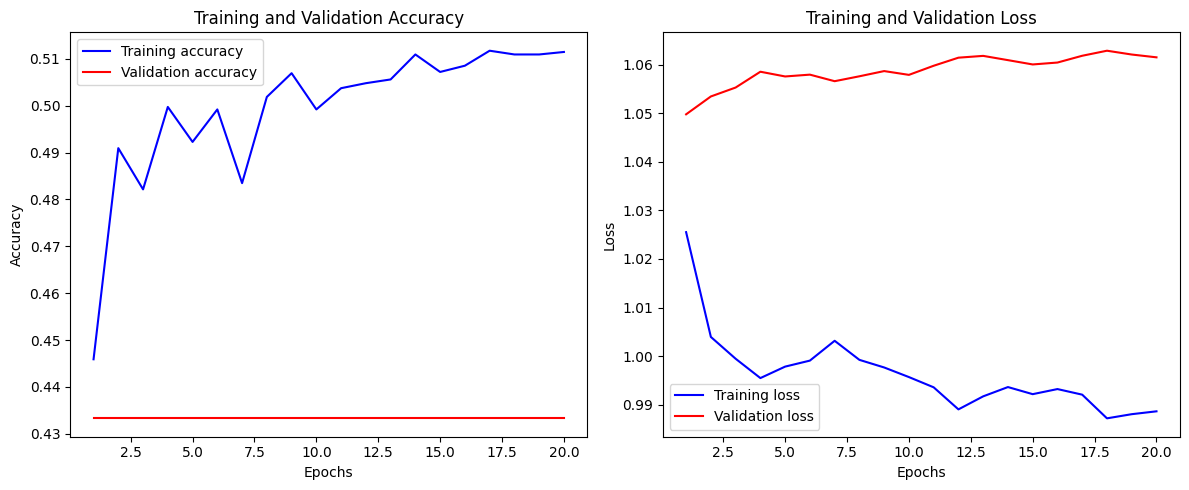

In [279]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [280]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model1.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true =df_test['揮拍軌跡正確度'].values.astype(int) 
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
整體驗證集準確度 (Overall Accuracy): 0.5536

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       122
     1分 (普通)     0.5536    1.0000    0.7127       692
      2分 (好)     0.0000    0.0000    0.0000       436

    accuracy                         0.5536      1250
   macro avg     0.1845    0.3333    0.2376      1250
weighted avg     0.3065    0.5536    0.3945      1250



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [287]:
model2=create_model(6)
epochs_metrics_2 = model2.fit(X_train[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 15)

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_87 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 58ms/step - accuracy: 0.3989 - loss: 1.0917 - val_accuracy: 0.3939 - val_loss: 1.0679
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.4593 - loss: 1.0547 - val_accuracy: 0.3939 - val_loss: 1.0600
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.4654 - loss: 1.0458 - val_accuracy: 0.3939 - val_loss: 1.0560
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.4657 - loss: 1.0481 - val_accuracy: 0.3939 - val_loss: 1.0583
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.4780 - loss: 1.0418 - val_accuracy: 0.3939 - val_loss: 1.0570
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.4777 - loss: 1.0433 - val_accuracy: 0.3939 - val_loss: 1.0580
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.4814 - loss: 1.0388 - val_accuracy: 0.3939 - val_loss: 1.0609
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.4846 - loss: 1.0360 - 

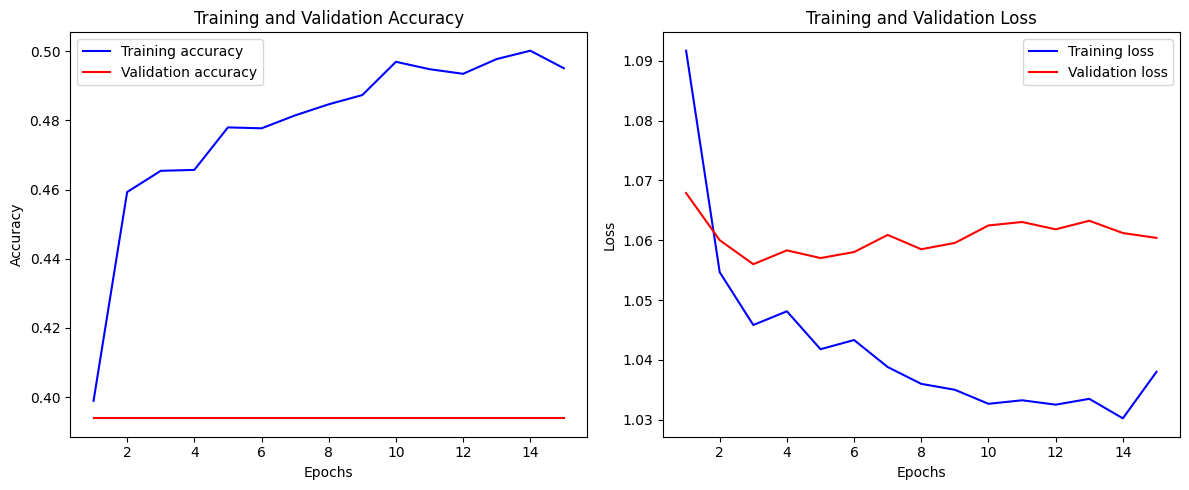

In [288]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [289]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model2.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true =df_test['揮拍速度流暢度'].values.astype(int) 
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
整體驗證集準確度 (Overall Accuracy): 0.5784

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       180
     1分 (普通)     0.5784    1.0000    0.7329       723
      2分 (好)     0.0000    0.0000    0.0000       347

    accuracy                         0.5784      1250
   macro avg     0.1928    0.3333    0.2443      1250
weighted avg     0.3345    0.5784    0.4239      1250



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [296]:
model3 =create_model(6)
epochs_metrics_3 = model3.fit(X_train[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 15)

Model: "sequential_86"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.3699 - loss: 1.1011 - val_accuracy: 0.3467 - val_loss: 1.0955
Epoch 2/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.3704 - loss: 1.0982 - val_accuracy: 0.3435 - val_loss: 1.0955
Epoch 3/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.3803 - loss: 1.0912 - val_accuracy: 0.3424 - val_loss: 1.0963
Epoch 4/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.3862 - loss: 1.0902 - val_accuracy: 0.3424 - val_loss: 1.0963
Epoch 5/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3792 - loss: 1.0928 - val_accuracy: 0.3424 - val_loss: 1.0960
Epoch 6/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3619 - loss: 1.0936 - val_accuracy: 0.3424 - val_loss: 1.0961
Epoch 7/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.3849 - loss: 1.0873 - val_accuracy: 0.3424 - val_loss: 1.0966
Epoch 8/15
234/234 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.3800 - loss: 1.0881 - 

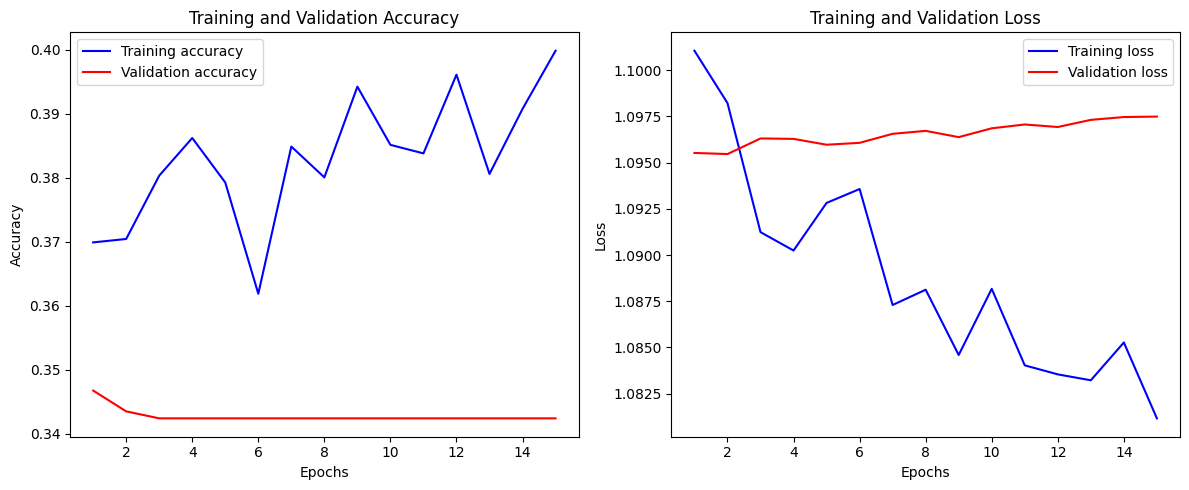

In [297]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [298]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model3.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true =df_test['手腕轉動時機正確度'].values.astype(int) 
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
整體驗證集準確度 (Overall Accuracy): 0.4336

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.4336    1.0000    0.6049       542
     1分 (普通)     0.0000    0.0000    0.0000       390
      2分 (好)     0.0000    0.0000    0.0000       318

    accuracy                         0.4336      1250
   macro avg     0.1445    0.3333    0.2016      1250
weighted avg     0.1880    0.4336    0.2623      1250



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [ ]:
model4 = create_model(6)
epochs_metrics_4 = model4.fit(X_train[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 40)

Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4001 - loss: 1.0867 - val_accuracy: 0.4066 - val_loss: 1.0776
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4256 - loss: 1.0827 - val_accuracy: 0.4066 - val_loss: 1.0781
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4374 - loss: 1.0789 - val_accuracy: 0.4066 - val_loss: 1.0782
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4432 - loss: 1.0738 - val_accuracy: 0.4066 - val_loss: 1.0789
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4459 - loss: 1.0757 - val_accuracy: 0.4066 - val_loss: 1.0780
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4457 - loss: 1.0740 - val_accuracy: 0.4066 - val_loss: 1.0774
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4464 - loss: 1.0732 - val_accuracy: 0.4066 - val_loss: 1.0787
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4477 - loss: 1.0703 - val_accu

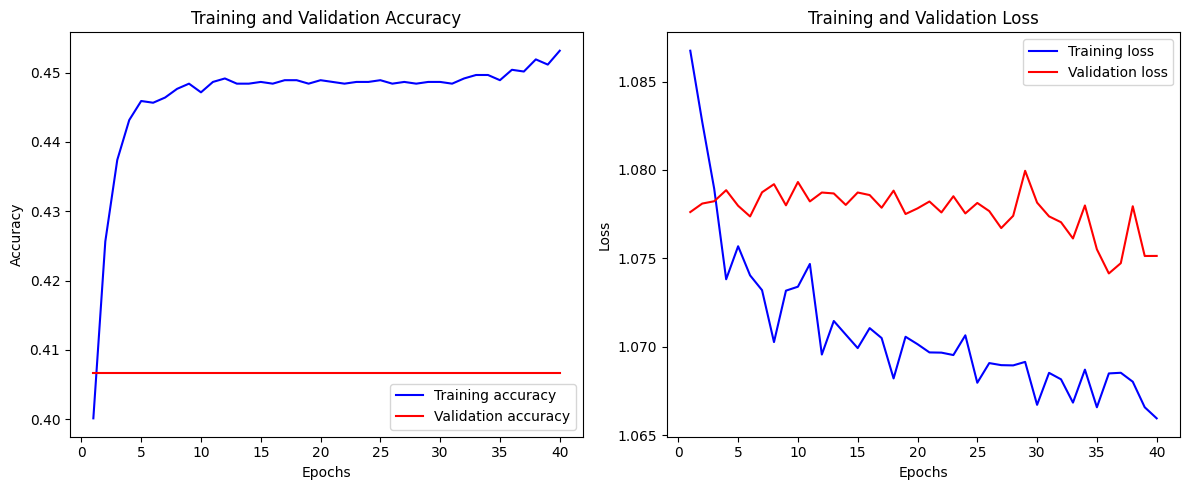

In [217]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [ ]:
model5=create_model(6)
epochs_metrics_5 = model5.fit(X_train[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 40)

Epoch 1/40
 88/253 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.4067 - loss: 1.0771

KeyboardInterrupt: 

In [223]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model5.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true =df_test['擊球位置正確度'].values.astype(int) 
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
整體驗證集準確度 (Overall Accuracy): 0.4408

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.5164    0.3343    0.4059       329
     1分 (普通)     0.4188    0.8528    0.5618       360
      2分 (好)     0.0000    0.0000    0.0000       257

    accuracy                         0.4408       946
   macro avg     0.3118    0.3957    0.3226       946
weighted avg     0.3390    0.4408    0.3549       946



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model5.predict(X_train) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = y1[val_indices[0]].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
整體驗證集準確度 (Overall Accuracy): 0.5656

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        38
     1分 (普通)     0.5618    0.9898    0.7168       491
      2分 (好)     0.7368    0.0394    0.0749       355

    accuracy                         0.5656       884
   macro avg     0.4329    0.3431    0.2639       884
weighted avg     0.6080    0.5656    0.4282       884



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

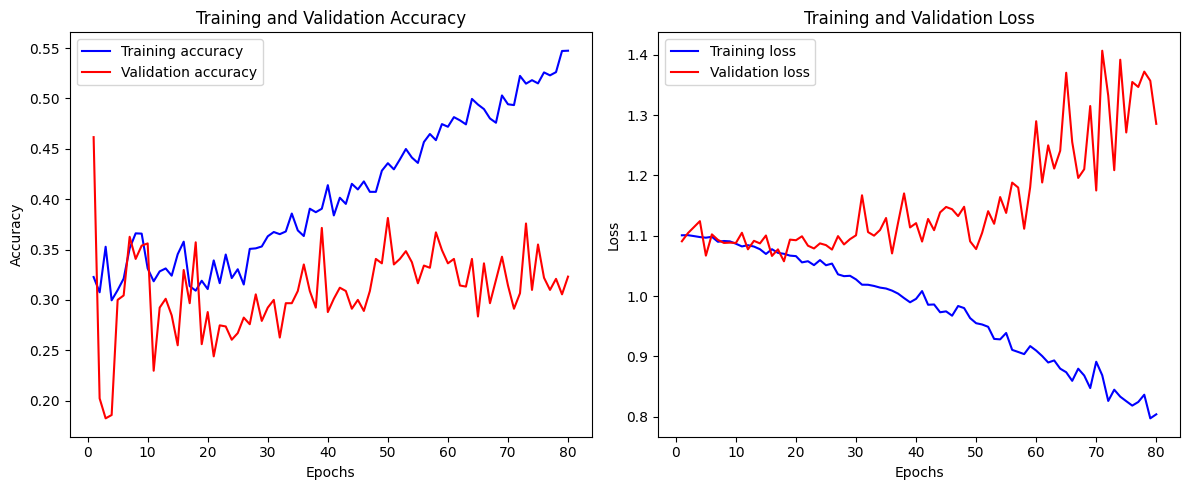

In [68]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [125]:
model6 =  create_model_2(6)
epochs_metrics_6 = model6.fit(X_train[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 15)

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5093 - loss: 0.9997 - val_accuracy: 0.4333 - val_loss: 1.0701
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5107 - loss: 0.9788 - val_accuracy: 0.4333 - val_loss: 1.0679
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5123 - loss: 0.9731 - val_accuracy: 0.4333 - val_loss: 1.0698
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5173 - loss: 0.9666 - val_accuracy: 0.4520 - val_loss: 1.0794
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5251 - loss: 0.9612 - val_accuracy: 0.4520 - val_loss: 1.0804
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5307 - loss: 0.9550 - val_accuracy: 0.4344 - val_loss: 1.0889
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5328 - loss: 0.9515 - val_accuracy: 0.4664 - val_loss: 1.0710
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5453 - loss: 0.9460 - val_accuracy: 0.

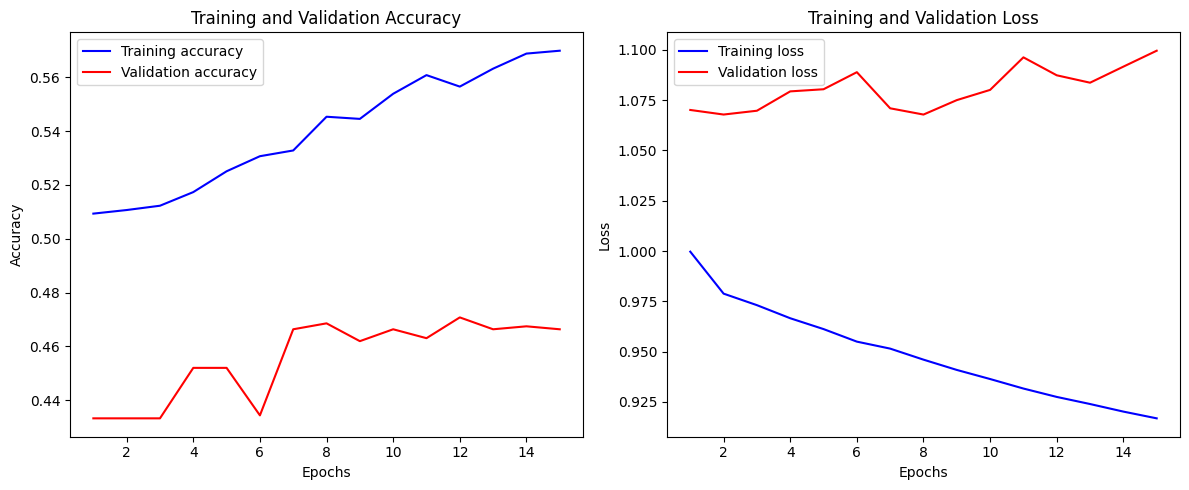

In [126]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_6.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [128]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba =  model6.predict(X_test) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.5936

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       122
     1分 (普通)     0.5910    0.8772    0.7062       692
      2分 (好)     0.6054    0.3096    0.4097       436

    accuracy                         0.5936      1250
   macro avg     0.3988    0.3956    0.3720      1250
weighted avg     0.5384    0.5936    0.5339      1250



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [147]:
model7 =  create_model_2(6)
epochs_metrics_7 = model7.fit(X_train[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 5)

Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_31 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4959 - loss: 1.0274 - val_accuracy: 0.3950 - val_loss: 1.0480
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4985 - loss: 1.0198 - val_accuracy: 0.3939 - val_loss: 1.0613
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4985 - loss: 1.0138 - val_accuracy: 0.3939 - val_loss: 1.0729
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4993 - loss: 1.0074 - val_accuracy: 0.3939 - val_loss: 1.0639
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5012 - loss: 1.0019 - val_accuracy: 0.3939 - val_loss: 1.0766


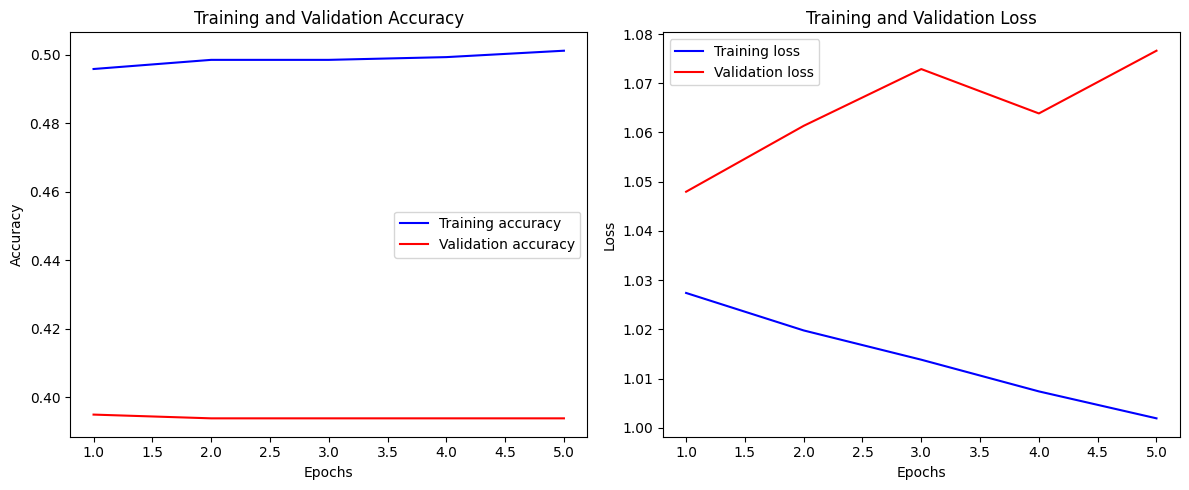

In [148]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_7.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [149]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model7.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = df_test['揮拍速度流暢度'].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
整體驗證集準確度 (Overall Accuracy): 0.5784

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       180
     1分 (普通)     0.5784    1.0000    0.7329       723
      2分 (好)     0.0000    0.0000    0.0000       347

    accuracy                         0.5784      1250
   macro avg     0.1928    0.3333    0.2443      1250
weighted avg     0.3345    0.5784    0.4239      1250



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [182]:
model8 =  create_model_2(6)
epochs_metrics_8 = model8.fit(X_train[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 20)

Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_42 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_41 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_39 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4028 - loss: 1.0788 - val_accuracy: 0.3272 - val_loss: 1.1017
Epoch 2/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4129 - loss: 1.0732 - val_accuracy: 0.3402 - val_loss: 1.1099
Epoch 3/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4250 - loss: 1.0662 - val_accuracy: 0.3489 - val_loss: 1.1024
Epoch 4/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4295 - loss: 1.0611 - val_accuracy: 0.3696 - val_loss: 1.1048
Epoch 5/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4520 - loss: 1.0551 - val_accuracy: 0.3772 - val_loss: 1.1077
Epoch 6/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4466 - loss: 1.0498 - val_accuracy: 0.3163 - val_loss: 1.1087
Epoch 7/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4683 - loss: 1.0440 - val_accuracy: 0.3663 - val_loss: 1.1121
Epoch 8/20
234/234 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4766 - loss: 1.0411 - val_accuracy: 0.

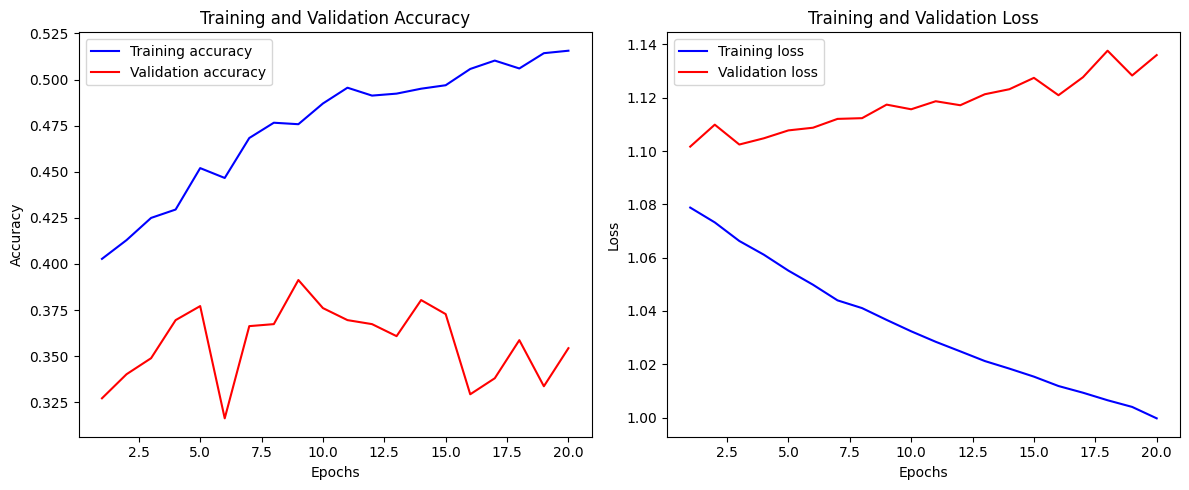

In [184]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_8.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [188]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model8.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = df_test['手腕轉動時機正確度'].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
整體驗證集準確度 (Overall Accuracy): 0.3688

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.3815    0.5018    0.4335       542
     1分 (普通)     0.2086    0.2231    0.2156       390
      2分 (好)     0.8500    0.3208    0.4658       318

    accuracy                         0.3688      1250
   macro avg     0.4800    0.3486    0.3716      1250
weighted avg     0.4467    0.3688    0.3737      1250



In [215]:
model9 =  create_model_2(6)
epochs_metrics_9 = model9.fit(X_train[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 20)

Model: "sequential_54"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_51 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_50 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_48 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3840 - loss: 1.1427 - val_accuracy: 0.4334 - val_loss: 1.0548
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4254 - loss: 1.0751 - val_accuracy: 0.4334 - val_loss: 1.0587
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4294 - loss: 1.0700 - val_accuracy: 0.4300 - val_loss: 1.0582
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4272 - loss: 1.0646 - val_accuracy: 0.4300 - val_loss: 1.0598
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4288 - loss: 1.0590 - val_accuracy: 0.4300 - val_loss: 1.0565
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4341 - loss: 1.0540 - val_accuracy: 0.4490 - val_loss: 1.0464
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4360 - loss: 1.0492 - val_accuracy: 0.4490 - val_loss: 1.0466
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4421 - loss: 1.0436 - val_accuracy: 0.

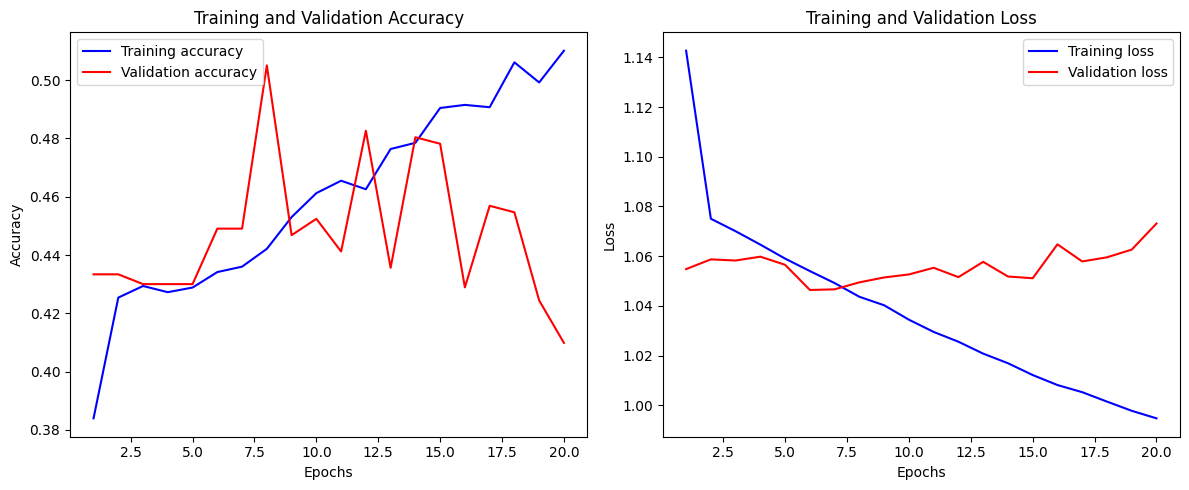

In [216]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_9.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [246]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model9.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = df_test['擊球時機正確度'].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
整體驗證集準確度 (Overall Accuracy): 0.4608

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.2975    0.1734    0.2191       271
     1分 (普通)     0.4768    0.8462    0.6100       572
      2分 (好)     0.5844    0.1106    0.1860       407

    accuracy                         0.4608      1250
   macro avg     0.4529    0.3767    0.3383      1250
weighted avg     0.4730    0.4608    0.3872      1250



In [253]:
model10 =  create_model_2(6)
epochs_metrics_10 = model10.fit(X_train[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 20)

Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_62 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_61 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_59 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3789 - loss: 1.0833 - val_accuracy: 0.2860 - val_loss: 1.1026
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3937 - loss: 1.0742 - val_accuracy: 0.3017 - val_loss: 1.0929
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4147 - loss: 1.0672 - val_accuracy: 0.2659 - val_loss: 1.1132
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4344 - loss: 1.0596 - val_accuracy: 0.2648 - val_loss: 1.1087
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4524 - loss: 1.0512 - val_accuracy: 0.2693 - val_loss: 1.1020
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4564 - loss: 1.0459 - val_accuracy: 0.2391 - val_loss: 1.1228
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4594 - loss: 1.0410 - val_accuracy: 0.2816 - val_loss: 1.1105
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4708 - loss: 1.0366 - val_accuracy: 0.

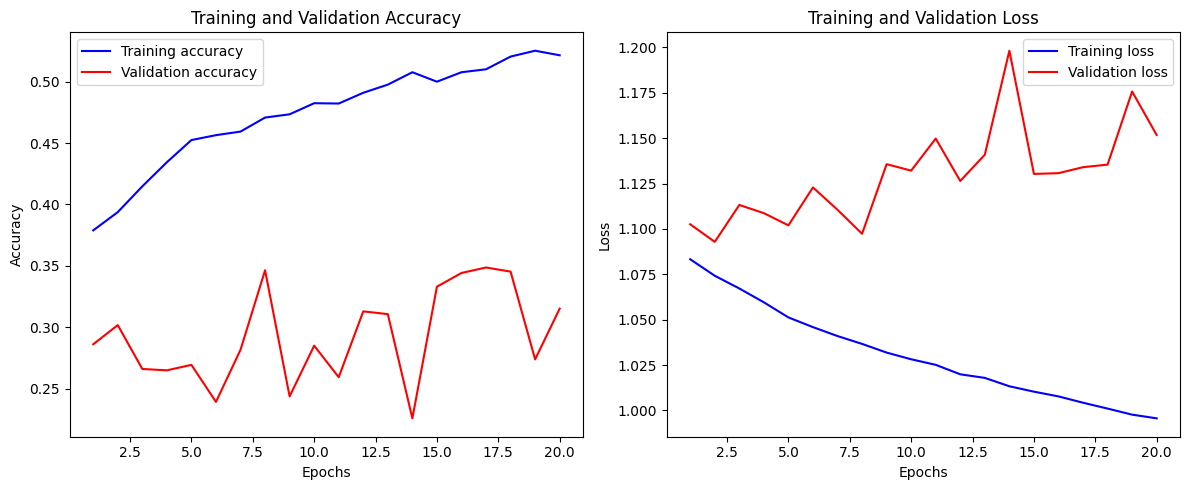

In [256]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_10.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [257]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

# 假設 model 是您訓練好的分類模型 (Loss='sparse_categorical_crossentropy')
# 假設 X_val 和 y_val 已經從訓練集和標籤中正確切分

# 1. 預測：輸出機率分佈 (Softmax output)
y_pred_proba = model10.predict(X_test) 

# 2. 獲取預測類別：找到機率最大的索引 (即預測的類別 0, 1, 或 2)
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# 3. 確保真實標籤是正確的整數格式
y_true = df_test['擊球位置正確度'].astype(int)
# 打印整體準確度 (供參考)
val_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體驗證集準確度 (Overall Accuracy): {val_accuracy:.4f}")
print("\n" + "="*50)

# 打印分類報告：顯示每個類別的 Precision, Recall, F1-score
print("詳細類別準確率報告 (Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
整體驗證集準確度 (Overall Accuracy): 0.4064

詳細類別準確率報告 (Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.4206    0.5178    0.4641       450
     1分 (普通)     0.3775    0.5044    0.4318       452
      2分 (好)     0.5109    0.1351    0.2136       348

    accuracy                         0.4064      1250
   macro avg     0.4363    0.3858    0.3699      1250
weighted avg     0.4301    0.4064    0.3827      1250



In [244]:
#手腕轉動時機正確度
epochs_metrics_3 = model3.fit(X_train[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 70)

Epoch 1/70


KeyboardInterrupt: 

In [ ]:
#擊球時機正確度
epochs_metrics_4 = model4.fit(X[train_indices[3]], y4[train_indices[3]],  validation_data=(X[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 50)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.3237 - loss: 1.1364 - val_accuracy: 0.3277 - val_loss: 1.0957
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.3947 - loss: 1.0877 - val_accuracy: 0.4366 - val_loss: 1.0707
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4279 - loss: 1.0744 - val_accuracy: 0.4366 - val_loss: 1.0661
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4250 - loss: 1.0744 - val_accuracy: 0.4366 - val_loss: 1.0651
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4229 - loss: 1.0751 - val_accuracy: 0.4366 - val_loss: 1.0642
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.4298 - loss: 1.0724 - val_accuracy: 0.4366 - val_loss: 1.0636
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4338 - loss: 1.0700 - val_accuracy: 0.4366 - val_loss: 1.0629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.4266 - loss: 1.0702 - 

In [ ]:
#擊球位置正確度(未train)
epochs_metrics_5 = model5.fit(X[train_indices[4]], y5[train_indices[4]],  validation_data=(X[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 40)

Epoch 1/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.3286 - loss: 1.1241 - val_accuracy: 0.3586 - val_loss: 1.0957
Epoch 2/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3737 - loss: 1.0898 - val_accuracy: 0.3586 - val_loss: 1.0901
Epoch 3/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3826 - loss: 1.0814 - val_accuracy: 0.3891 - val_loss: 1.0858
Epoch 4/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3951 - loss: 1.0722 - val_accuracy: 0.4427 - val_loss: 1.0626
Epoch 5/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.4470 - loss: 1.0294 - val_accuracy: 0.4784 - val_loss: 1.0057
Epoch 6/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.4988 - loss: 0.9925 - val_accuracy: 0.5321 - val_loss: 0.9468
Epoch 7/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.5114 - loss: 0.9672 - val_accuracy: 0.5331 - val_loss: 0.9368
Epoch 8/40
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.5263 - loss: 0.9508 - 

In [ ]:
model1.save("models/model1.keras")
model2.save("models/model2.keras")
model3.save("models/model3.keras")
model4.save("models/model4.keras")
model5.save("models/model5.keras")

In [ ]:
import os
import random
import numpy as np

# 設定資料夾路徑
right_dir = "righthand"
left_dir = "lefthand"

lefthand_files = sorted(os.listdir(left_dir))
righthand_files = sorted(os.listdir(right_dir))
# 去掉.csv副檔名
lefthand_files = [os.path.splitext(f)[0] for f in lefthand_files if f.endswith(".csv")]
righthand_files = [os.path.splitext(f)[0] for f in righthand_files if f.endswith(".csv")]

# 打亂
random.shuffle(lefthand_files)
random.shuffle(righthand_files)

# 各自取一半做測試集
lefthand_test = lefthand_files[:len(lefthand_files)//2]
lefthand_train = lefthand_files[len(lefthand_files)//2:]

righthand_test = righthand_files[:len(righthand_files)//2]
righthand_train = righthand_files[len(righthand_files)//2:]

# 合併並只存檔案名稱
train_files_name = lefthand_train + righthand_train
test_files_name = lefthand_test + righthand_test
random.shuffle(train_files_name)
random.shuffle(test_files_name)


print("訓練集:", train_files_name)
print("測試集:", test_files_name)
print("訓練集數量:", len(train_files_name))
print("測試集數量:", len(test_files_name))



訓練集: ['righthand_5', 'righthand_6', 'lefthand_5', 'lefthand_6', 'righthand_9', 'righthand_8', 'lefthand_11', 'righthand_2', 'lefthand_10', 'lefthand_4']
測試集: ['lefthand_8', 'lefthand_2', 'righthand_4', 'righthand_10', 'lefthand_7', 'righthand_7', 'lefthand_3', 'righthand_3', 'righthand_11', 'lefthand_9']
訓練集數量: 10
測試集數量: 10


In [ ]:
import json
import pandas as pd

# 讀左手 JSON
with open('./segments_with_scores_left.json', 'r', encoding='utf-8') as file:
    data_left = json.load(file)
df2 = pd.DataFrame(data_left)

# 讀右手 JSON
with open('./segments_with_scores_right.json', 'r', encoding='utf-8') as file:
    data_right = json.load(file)
df_right = pd.DataFrame(data_right)

# 合併左右手資料
df2 = pd.concat([df2, df_right], ignore_index=True)

print(df2.head)
print(df2.shape)


<bound method NDFrame.head of               檔名  揮拍軌跡正確度  揮拍速度流暢度  手腕轉動時機正確度  擊球時機正確度  擊球位置正確度  \
0     lefthand_2        1        1          1        1        1   
1     lefthand_3        1        1          1        1        1   
2     lefthand_4        1        1          1        1        1   
3     lefthand_5        1        1          1        1        1   
4     lefthand_6        1        1          1        1        1   
5     lefthand_7        1        1          1        1        1   
6     lefthand_8        1        1          1        1        1   
7     lefthand_9        1        1          1        1        1   
8    lefthand_10        1        1          1        1        1   
9    lefthand_11        1        1          1        1        1   
10   righthand_2        5        5          5        5        5   
11   righthand_3        5        5          5        5        5   
12   righthand_4        5        5          5        5        5   
13   righthand_5        5       

In [ ]:
from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()

    std_x_acc2 = scaler.fit_transform(np.concatenate(df2['x軸加速度'].tolist()).reshape(-1, 1))
    std_y_acc2 = scaler.fit_transform(np.concatenate(df2['y軸加速度'].tolist()).reshape(-1, 1))
    std_z_acc2 = scaler.fit_transform(np.concatenate(df2['z軸加速度'].tolist()).reshape(-1, 1))
    std_x_ang2 = scaler.fit_transform(np.concatenate(df2['x軸角加速度'].tolist()).reshape(-1, 1))
    std_y_ang2 = scaler.fit_transform(np.concatenate(df2['y軸角加速度'].tolist()).reshape(-1, 1))
    std_z_ang2 = scaler.fit_transform(np.concatenate(df2['z軸角加速度'].tolist()).reshape(-1, 1))

    X2 = np.concatenate((std_x_acc2, std_y_acc2, std_z_acc2, std_x_ang2, std_y_ang2, std_z_ang2), axis = 1).reshape(-1, 125, 6)
    print(X2.shape)

(20, 125, 6)


In [ ]:
# 把檔名設成索引，方便用檔名抓資料
df2_indexed = df2.set_index("檔名")
# 依照 train_files_name 的順序來抓對應的 y
y1_train2 = df2.set_index("檔名").loc[train_files_name, "揮拍軌跡正確度"].values
y1_test2  = df2.set_index("檔名").loc[test_files_name,  "揮拍軌跡正確度"].values
# 按照 train_files_name/test_files_name 的順序取得特徵和標籤
X_train2 = np.stack([X2[df2_indexed.index.get_loc(f)] for f in train_files_name])
X_test2  = np.stack([X2[df2_indexed.index.get_loc(f)] for f in test_files_name])

# 訓練集
y1_train2 = np.array([1 if y == 5 else 0 for y in y1_train2])

# 測試集
y1_test2 = np.array([1 if y == 5 else 0 for y in y1_test2])

print(y1_train2)
print(y1_test2)


[1 1 0 0 1 1 0 1 0 0]
[0 0 1 1 0 1 0 1 1 0]


In [ ]:
from tensorflow.keras.models import load_model

# 重新載入模型
left_right_model1 = load_model("models/model1.keras")

for layer in left_right_model1.layers:
    layer.trainable=False

left_right_model1.add(layers.Dropout(0.2))
left_right_model1.add(layers.Dense(1, activation="sigmoid"))
left_right_model1.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,052 (11.93 KB)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 1,523 (5.95 KB)

 Optimizer params: 1,525 (5.96 KB)

In [ ]:
left_right_model1.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 訓練模型
left_right_metrics = left_right_model1.fit(
    X_train2,
    y1_train2,
    batch_size=1,
    epochs=80
)


Epoch 1/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5000 - loss: 0.7166
Epoch 2/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 0.7175
Epoch 3/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.7133
Epoch 4/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 0.7203
Epoch 5/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5000 - loss: 0.7229
Epoch 6/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 0.7089
Epoch 7/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.7729
Epoch 8/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.5000 - loss: 0.7693
Epoch 9/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 0.7403
Epoch 10/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.5000 - loss: 0.7541
Epoch 11/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.7549
Epoch 12/80
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.7449
E

In [ ]:

# 測試
loss, accuracy = left_right_model1.evaluate(X_test2, y1_test2, batch_size=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

import numpy as np

# 在測試集上做預測
y_pred_prob = left_right_model1.predict(X_test2)   # (N,1) 機率值
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# 印出實際標籤和預測標籤
for i in range(len(y1_test2)):
    print(f"檔名: {test_files_name[i]}, 預測 = {y_pred[i]}, 實際 = {y1_test2[i]}")



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.5942
Test Loss: 0.594197154045105
Test Accuracy: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
檔名: lefthand_8, 預測 = 0, 實際 = 0
檔名: lefthand_2, 預測 = 0, 實際 = 0
檔名: righthand_4, 預測 = 1, 實際 = 1
檔名: righthand_10, 預測 = 1, 實際 = 1
檔名: lefthand_7, 預測 = 0, 實際 = 0
檔名: righthand_7, 預測 = 1, 實際 = 1
檔名: lefthand_3, 預測 = 0, 實際 = 0
檔名: righthand_3, 預測 = 1, 實際 = 1
檔名: righthand_11, 預測 = 1, 實際 = 1
檔名: lefthand_9, 預測 = 0, 實際 = 0


In [ ]:
new_model =Sequential()
new_model.add(Input(shape=(125, 6)))
new_model.add(layers.LSTM(units=16))
new_model.add(layers.Dropout(0.2))
new_model.add(layers.Dense(3, activation='softmax'))
new_model.add(layers.Dropout(0.2))
new_model.add(layers.Dense(1, activation='sigmoid')) 
new_model.summary()
new_model.compile(optimizer=Adam(learning_rate = 0.0001), loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 3)              │            51 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,527 (5.96 KB)

 Trainable params: 1,527 (5.96 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = new_model.fit(
    X_train2, y1_train2,
    batch_size=1,
    epochs=80
)

Epoch 1/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5000 - loss: 0.7633
Epoch 2/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.7292  
Epoch 3/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5000 - loss: 0.7955  
Epoch 4/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.7683
Epoch 5/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5000 - loss: 0.7484
Epoch 6/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.7548
Epoch 7/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5000 - loss: 0.7417
Epoch 8/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.6709  
Epoch 9/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5000 - loss: 0.7172
Epoch 10/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.7415
Epoch 11/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.7386
Epoch 12/80
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - acc

In [ ]:
# 在測試集上評估
loss, accuracy = new_model.evaluate(X_test2, y1_test2, batch_size=1)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

y_pred_prob = new_model.predict(X_test2)   # (N,1) 機率值
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

# 印出實際標籤和預測標籤
for i in range(len(y1_test2)):
    print(f"檔名: {test_files_name[i]}, 預測 = {y_pred[i]}, 實際 = {y1_test2[i]}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.7055  
Test Loss: 0.7055212259292603
Test Accuracy: 0.5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
檔名: righthand_9, 預測 = 1, 實際 = 1
檔名: lefthand_3, 預測 = 1, 實際 = 0
檔名: lefthand_9, 預測 = 1, 實際 = 0
檔名: righthand_2, 預測 = 1, 實際 = 1
檔名: lefthand_11, 預測 = 1, 實際 = 0
檔名: righthand_8, 預測 = 1, 實際 = 1
檔名: lefthand_2, 預測 = 1, 實際 = 0
檔名: righthand_4, 預測 = 1, 實際 = 1
檔名: righthand_3, 預測 = 1, 實際 = 1
檔名: lefthand_7, 預測 = 1, 實際 = 0


In [ ]:
epochs_metrics_6 = model6.fit(X[train_indices[0]], y1[train_indices[0]],  validation_data=(X[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 30)
model6.save("model6.h5")

NameError: name 'model6' is not defined

In [ ]:
from tensorflow.keras.models import load_model

transfer_model_6 = load_model("model6.h5")

for layer in transfer_model_6.layers:
    layer.trainable = False
    
for layer in transfer_model_6.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

transfer_model_6.add(layers.Dropout(0.2))   
transfer_model_6.add(layers.Dense(score_category_count, activation='softmax'))
transfer_model_6.summary()

conv1d_30: trainable = False
max_pooling1d_30: trainable = False
flatten_15: trainable = False
dense_116: trainable = False
Model: "sequential_101"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_30 (Conv1D)          (None, 116, 16)           976       
                                                                 
 max_pooling1d_30 (MaxPooli  (None, 38, 16)            0         
 ng1D)                                                           
                                                                 
 flatten_15 (Flatten)        (None, 608)               0         
                                                                 
 dense_116 (Dense)           (None, 3)                 1827      
                                                                 
 dropout_106 (Dropout)       (None, 3)                 0         
                                                            

: 

In [ ]:
transfer_epochs_metrics_6 = model6.fit(X[train_indices[1]], y1[train_indices[1]],  validation_data=(X[val_indices[1]], y1[val_indices[1]]), batch_size = 16, epochs = 30)

Epoch 1/30
61/61 [==============================] - 0s 8ms/step - loss: 0.3174 - accuracy: 0.8913 - val_loss: 1.0837 - val_accuracy: 0.5884
Epoch 2/30
61/61 [==============================] - 0s 7ms/step - loss: 0.3192 - accuracy: 0.8934 - val_loss: 1.1271 - val_accuracy: 0.5955
Epoch 3/30
61/61 [==============================] - 0s 7ms/step - loss: 0.3153 - accuracy: 0.8944 - val_loss: 1.1103 - val_accuracy: 0.5968
Epoch 4/30
61/61 [==============================] - 0s 8ms/step - loss: 0.3121 - accuracy: 0.8934 - val_loss: 1.1010 - val_accuracy: 0.5944
Epoch 5/30
61/61 [==============================] - 0s 7ms/step - loss: 0.3123 - accuracy: 0.8965 - val_loss: 1.1284 - val_accuracy: 0.5968
Epoch 6/30
61/61 [==============================] - 0s 8ms/step - loss: 0.3088 - accuracy: 0.8954 - val_loss: 1.1180 - val_accuracy: 0.5994
Epoch 7/30
61/61 [==============================] - 0s 8ms/step - loss: 0.3083 - accuracy: 0.8986 - val_loss: 1.1093 - val_accuracy: 0.5965
Epoch 8/30
61/61 [==

: 

In [ ]:
#揮拍速度流暢度
epochs_metrics_7 = model7.fit(X[train_indices[1]], y2[train_indices[1]],  validation_data=(X[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 25)
model7.save("model7.h5")

Epoch 1/25
64/64 [==============================] - 3s 31ms/step - loss: 1.0402 - accuracy: 0.4787 - val_loss: 1.0054 - val_accuracy: 0.5046
Epoch 2/25
64/64 [==============================] - 1s 23ms/step - loss: 1.0130 - accuracy: 0.5045 - val_loss: 0.9949 - val_accuracy: 0.5046
Epoch 3/25
64/64 [==============================] - 2s 25ms/step - loss: 0.9964 - accuracy: 0.5045 - val_loss: 0.9848 - val_accuracy: 0.5046
Epoch 4/25
64/64 [==============================] - 1s 21ms/step - loss: 0.9759 - accuracy: 0.5035 - val_loss: 0.9744 - val_accuracy: 0.5080
Epoch 5/25
64/64 [==============================] - 2s 27ms/step - loss: 0.9577 - accuracy: 0.5164 - val_loss: 0.9633 - val_accuracy: 0.5048
Epoch 6/25
64/64 [==============================] - 2s 27ms/step - loss: 0.9372 - accuracy: 0.5055 - val_loss: 0.9542 - val_accuracy: 0.5418
Epoch 7/25
64/64 [==============================] - 1s 19ms/step - loss: 0.9214 - accuracy: 0.5619 - val_loss: 0.9426 - val_accuracy: 0.5220
Epoch 8/25
64

c:\Users\gordo\Downloads\tf-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 

In [ ]:
from tensorflow.keras.models import load_model

transfer_model_7 = load_model("model7.h5")

for layer in transfer_model_7.layers:
    layer.trainable = False
    
for layer in transfer_model_7.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

transfer_model_7.add(layers.Dropout(0.2))   
transfer_model_7.add(layers.Dense(score_category_count, activation='softmax'))
transfer_model_7.summary()

conv1d_21: trainable = False
max_pooling1d_21: trainable = False
flatten_11: trainable = False
dense_92: trainable = False
Model: "sequential_87"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_21 (Conv1D)          (None, 116, 16)           976       
                                                                 
 max_pooling1d_21 (MaxPooli  (None, 38, 16)            0         
 ng1D)                                                           
                                                                 
 flatten_11 (Flatten)        (None, 608)               0         
                                                                 
 dense_92 (Dense)            (None, 3)                 1827      
                                                                 
 dropout_118 (Dropout)       (None, 3)                 0         
                                                              

: 

In [ ]:
#手腕轉動時機正確度
epochs_metrics_8 = model8.fit(X[train_indices[2]], y3[train_indices[2]],  validation_data=(X[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 70)
model8.save("model8.h5")

Epoch 1/70
63/63 [==============================] - 3s 33ms/step - loss: 1.1491 - accuracy: 0.3463 - val_loss: 1.0944 - val_accuracy: 0.4359
Epoch 2/70
63/63 [==============================] - 2s 29ms/step - loss: 1.0532 - accuracy: 0.5629 - val_loss: 1.0673 - val_accuracy: 0.4558
Epoch 3/70
63/63 [==============================] - 1s 22ms/step - loss: 1.0262 - accuracy: 0.5190 - val_loss: 1.0595 - val_accuracy: 0.4441
Epoch 4/70
63/63 [==============================] - 2s 25ms/step - loss: 1.0022 - accuracy: 0.5190 - val_loss: 1.0426 - val_accuracy: 0.4854
Epoch 5/70
63/63 [==============================] - 2s 28ms/step - loss: 0.9792 - accuracy: 0.5369 - val_loss: 1.0276 - val_accuracy: 0.4746
Epoch 6/70
63/63 [==============================] - 2s 32ms/step - loss: 0.9584 - accuracy: 0.5519 - val_loss: 1.0186 - val_accuracy: 0.4931
Epoch 7/70
63/63 [==============================] - 2s 26ms/step - loss: 0.9392 - accuracy: 0.6078 - val_loss: 1.0092 - val_accuracy: 0.4799
Epoch 8/70
63

c:\Users\gordo\Downloads\tf-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 

In [ ]:
from tensorflow.keras.models import load_model

transfer_model_8 = load_model("model8.h5")

for layer in transfer_model_8.layers:
    layer.trainable = False
    
for layer in transfer_model_8.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

transfer_model_8.add(layers.Dropout(0.2))   
transfer_model_8.add(layers.Dense(score_category_count, activation='softmax'))
transfer_model_8.summary()

conv1d_22: trainable = False
max_pooling1d_22: trainable = False
flatten_12: trainable = False
dense_93: trainable = False
Model: "sequential_88"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_22 (Conv1D)          (None, 116, 16)           976       
                                                                 
 max_pooling1d_22 (MaxPooli  (None, 38, 16)            0         
 ng1D)                                                           
                                                                 
 flatten_12 (Flatten)        (None, 608)               0         
                                                                 
 dense_93 (Dense)            (None, 3)                 1827      
                                                                 
 dropout_120 (Dropout)       (None, 3)                 0         
                                                              

: 

In [ ]:
transfer_epochs_metrics_8 = model8.fit(X[train_indices[1]], y3[train_indices[1]],  validation_data=(X[val_indices[1]], y3[val_indices[1]]), batch_size = 16, epochs = 70)

Epoch 1/70
61/61 [==============================] - 0s 4ms/step - loss: 0.8981 - accuracy: 0.5961 - val_loss: 0.9493 - val_accuracy: 0.5957
Epoch 2/70
61/61 [==============================] - 0s 4ms/step - loss: 0.8543 - accuracy: 0.6197 - val_loss: 0.9159 - val_accuracy: 0.6015
Epoch 3/70
61/61 [==============================] - 0s 5ms/step - loss: 0.8207 - accuracy: 0.6208 - val_loss: 0.9088 - val_accuracy: 0.5988
Epoch 4/70
61/61 [==============================] - 0s 4ms/step - loss: 0.7887 - accuracy: 0.6475 - val_loss: 0.8697 - val_accuracy: 0.6165
Epoch 5/70
61/61 [==============================] - 0s 4ms/step - loss: 0.7604 - accuracy: 0.6588 - val_loss: 0.8447 - val_accuracy: 0.6218
Epoch 6/70
61/61 [==============================] - 0s 4ms/step - loss: 0.7460 - accuracy: 0.6629 - val_loss: 0.8364 - val_accuracy: 0.6220
Epoch 7/70
61/61 [==============================] - 0s 5ms/step - loss: 0.7235 - accuracy: 0.6793 - val_loss: 0.8600 - val_accuracy: 0.6234
Epoch 8/70
61/61 [==

: 

In [ ]:
#擊球時機正確度
epochs_metrics_9 = model9.fit(X[train_indices[3]], y4[train_indices[3]],  validation_data=(X[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 50)
model9.save("model9.h5")

Epoch 1/50
62/62 [==============================] - 2s 30ms/step - loss: 1.0320 - accuracy: 0.4990 - val_loss: 1.0163 - val_accuracy: 0.5530
Epoch 2/50
62/62 [==============================] - 2s 31ms/step - loss: 0.9844 - accuracy: 0.5121 - val_loss: 0.9746 - val_accuracy: 0.5634
Epoch 3/50
62/62 [==============================] - 2s 27ms/step - loss: 0.9440 - accuracy: 0.5302 - val_loss: 0.9895 - val_accuracy: 0.5735
Epoch 4/50
62/62 [==============================] - 2s 29ms/step - loss: 0.9099 - accuracy: 0.5373 - val_loss: 0.9381 - val_accuracy: 0.5793
Epoch 5/50
62/62 [==============================] - 2s 29ms/step - loss: 0.8737 - accuracy: 0.5454 - val_loss: 0.9276 - val_accuracy: 0.5953
Epoch 6/50
62/62 [==============================] - 2s 26ms/step - loss: 0.8547 - accuracy: 0.5514 - val_loss: 0.9009 - val_accuracy: 0.5889
Epoch 7/50
62/62 [==============================] - 2s 28ms/step - loss: 0.8370 - accuracy: 0.5565 - val_loss: 0.8911 - val_accuracy: 0.5895
Epoch 8/50
62

c:\Users\gordo\Downloads\tf-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 

In [ ]:
#擊球位置正確度(未train)
epochs_metrics_10 = model10.fit(X[train_indices[4]], y5[train_indices[4]],  validation_data=(X[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 40)
model10.save("model10.h5")

Epoch 1/40
63/63 [==============================] - 2s 24ms/step - loss: 0.9501 - accuracy: 0.5495 - val_loss: 0.9220 - val_accuracy: 0.5206
Epoch 2/40
63/63 [==============================] - 1s 21ms/step - loss: 0.9106 - accuracy: 0.5656 - val_loss: 0.9052 - val_accuracy: 0.5259
Epoch 3/40
63/63 [==============================] - 1s 23ms/step - loss: 0.8808 - accuracy: 0.5756 - val_loss: 0.9242 - val_accuracy: 0.5121
Epoch 4/40
63/63 [==============================] - 2s 28ms/step - loss: 0.8566 - accuracy: 0.6036 - val_loss: 0.9038 - val_accuracy: 0.5270
Epoch 5/40
63/63 [==============================] - 2s 26ms/step - loss: 0.8310 - accuracy: 0.6106 - val_loss: 0.9045 - val_accuracy: 0.5243
Epoch 6/40
63/63 [==============================] - 2s 26ms/step - loss: 0.8158 - accuracy: 0.6206 - val_loss: 0.9135 - val_accuracy: 0.5206
Epoch 7/40
63/63 [==============================] - 2s 28ms/step - loss: 0.7943 - accuracy: 0.6416 - val_loss: 0.9218 - val_accuracy: 0.5081
Epoch 8/40
63

c:\Users\gordo\Downloads\tf-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


: 

In [74]:
import matplotlib.pyplot as plt

In [75]:
#plot(to check whether overfit or not)
def draw_val_loss(metrics):
    plt.plot(metrics.history['loss'], label='loss')
    plt.plot(metrics.history['val_loss'], label='val_loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


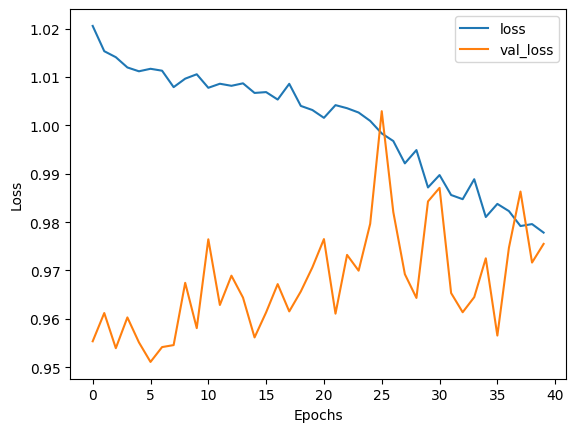

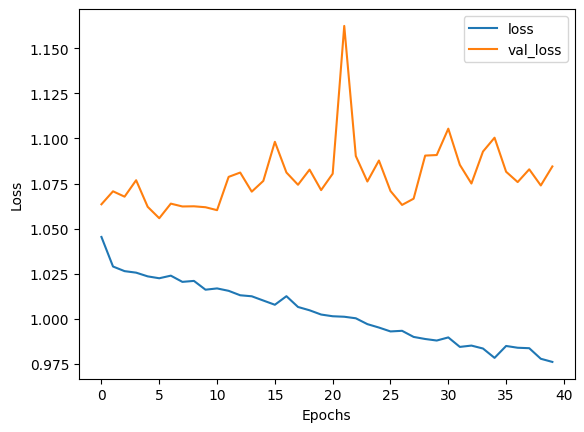

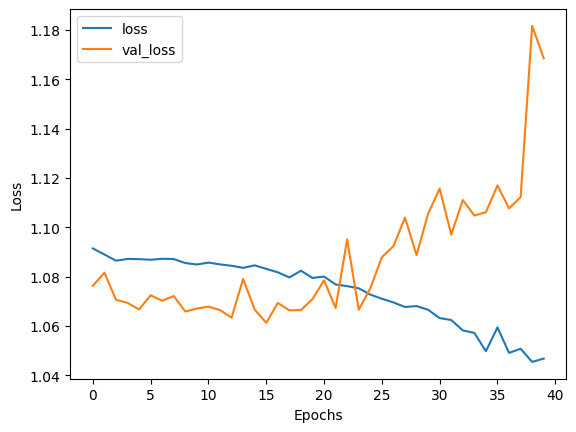

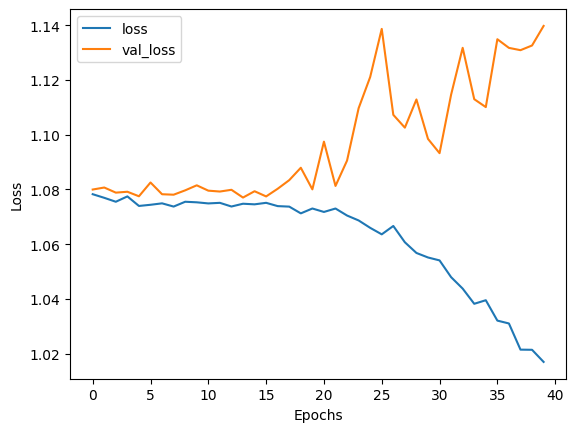

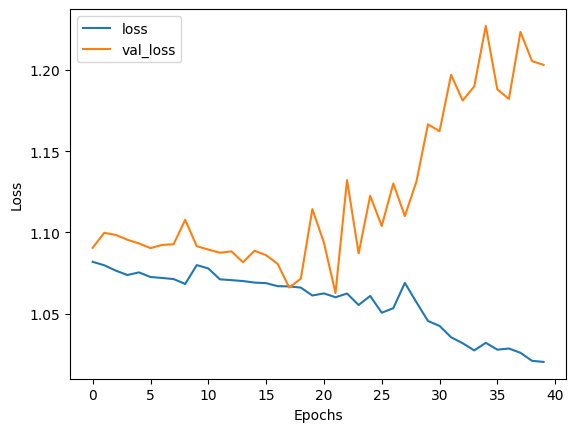

NameError: name 'epochs_metrics_6' is not defined

In [76]:
draw_val_loss(epochs_metrics_1)
draw_val_loss(epochs_metrics_2)
draw_val_loss(epochs_metrics_3)
draw_val_loss(epochs_metrics_4)
draw_val_loss(epochs_metrics_5)
draw_val_loss(epochs_metrics_6)
draw_val_loss(epochs_metrics_7)
draw_val_loss(epochs_metrics_8)
draw_val_loss(epochs_metrics_9)
draw_val_loss(epochs_metrics_10)

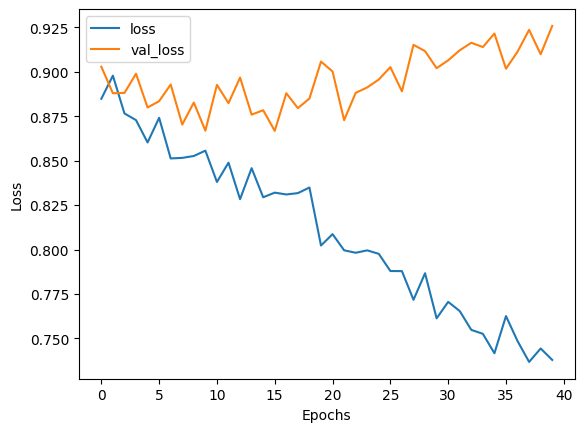

: 

In [ ]:
draw_val_loss(epochs_metrics_1)

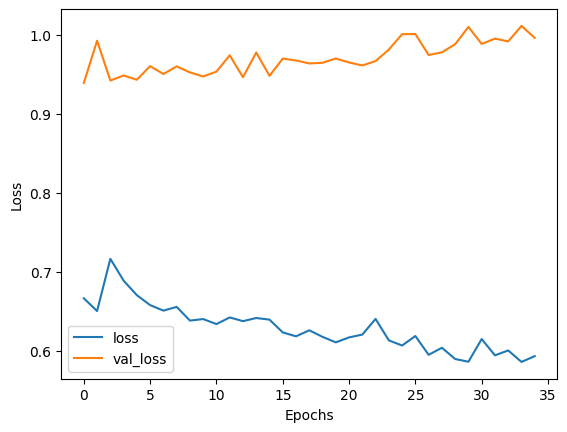

: 

In [ ]:
draw_val_loss(epochs_metrics_2)

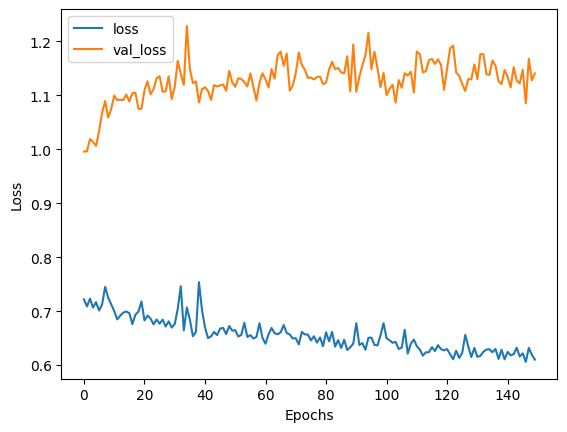

: 

In [ ]:
draw_val_loss(epochs_metrics_3)

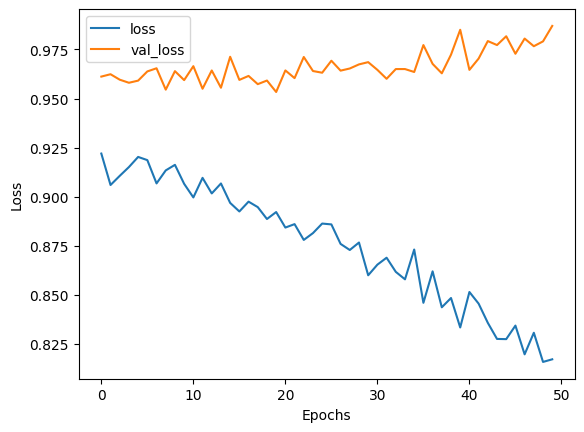

: 

In [ ]:
draw_val_loss(epochs_metrics_4)

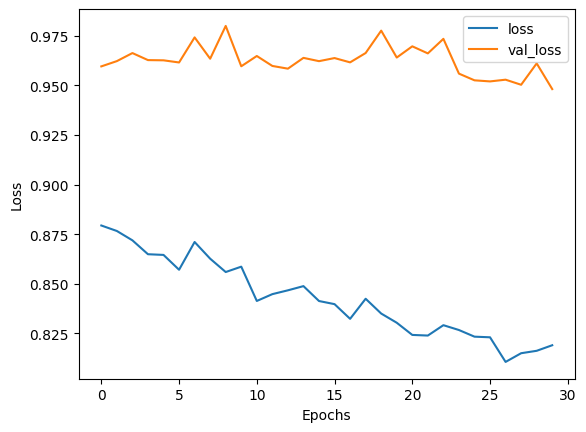

: 

In [ ]:
draw_val_loss(epochs_metrics_5) 

In [ ]:
def show_predict_result(model, x_test, y_test):
    ans = model.predict(x_test)
    predicted_values = np.argmax(ans, axis=1)
    true_values = y_test
    #print('Predicted values:\n',predicted_values)
    #print('True values:\n', true_values)
    count = 0
    for i in range(len(true_values)):
        if predicted_values[i] == true_values[i]:
            count += 1
    accuracy = count/len(true_values)
    print('accuracy=', accuracy)
    return (accuracy, predicted_values)

In [ ]:
acc1, predicted_value1 = show_predict_result(model1, X[test_indices], y1[test_indices])
acc2, predicted_value2 = show_predict_result(model2, X[test_indices], y2[test_indices])
acc3, predicted_value3 = show_predict_result(model3, X[test_indices], y3[test_indices]) 
acc4, predicted_value4 = show_predict_result(model4, X[test_indices], y4[test_indices]) 
acc5, predicted_value5 = show_predict_result(model5, X[test_indices], y5[test_indices])

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
accuracy= 0.6575943810359964
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
accuracy= 0.5021949078138718
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
accuracy= 0.6769095697980685
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
accuracy= 0.5627743634767339
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
accuracy= 0.5487269534679543


In [ ]:
from joblib import dump, load

: 

In [ ]:
dump(model1, 'models/model1_cnn.joblib')
dump(model2, 'models/model2_cnn.joblib')
dump(model3, 'models/model3_cnn.joblib')
dump(model4, 'models/model4_cnn.joblib')
dump(model5, 'models/model5_cnn.joblib')

['models/model5_cnn.joblib']

: 

以lstm的模型來預測分數及生成評語

In [ ]:
#事先保存
test_indices=[145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576, 577, 578, 579, 580, 787, 788, 789, 790, 791, 792, 793, 794, 795, 796, 797, 798, 799, 800, 801, 802, 803, 804, 805, 806, 807, 808, 809, 810, 811, 812, 813, 814, 815, 816, 1026, 1027, 1028, 1029, 1030, 1031, 1032, 1033, 1034, 1035, 1036, 1037, 1038, 1039, 1040, 1041, 1042, 1043, 1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053, 1054, 1055, 1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126, 1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1425, 1426, 1427, 1428, 1429, 1430, 1431, 1432, 1433, 1434, 1435, 1436, 1437, 1438, 1439, 1440, 1441, 1442, 1443, 1444, 1535, 1536, 1537, 1538, 1539, 1540, 1541, 1542, 1543, 1544, 1545, 1546, 1547, 1548, 1549, 1550, 1551, 1552, 1553, 1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561, 1562, 1563, 1564, 1625, 1626, 1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 1639, 1640, 1641, 1642, 1643, 1644, 1645, 1646, 1647, 1648, 1649, 1650, 1651, 1652, 1653, 1654, 1775, 1776, 1777, 1778, 1779, 1780, 1781, 1782, 1783, 1784, 1785, 1786, 1787, 1788, 1789, 1790, 1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 1811, 1812, 1813, 1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833, 1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844, 1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855, 1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100, 2101, 2102, 2313, 2314, 2315, 2316, 2317, 2318, 2319, 2320, 2321, 2322, 2323, 2324, 2325, 2326, 2327, 2328, 2329, 2330, 2331, 2332, 2333, 2334, 2335, 2336, 2337, 2338, 2339, 2340, 2341, 2342, 2433, 2434, 2435, 2436, 2437, 2438, 2439, 2440, 2441, 2442, 2443, 2444, 2445, 2446, 2447, 2448, 2449, 2450, 2451, 2452, 2453, 2454, 2455, 2456, 2457, 2458, 2459, 2460, 2461, 2462, 2869, 2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 2889, 2890, 2891, 2892, 2893, 2894, 2895, 2896, 2897, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2912, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 2928, 2959, 2960, 2961, 2962, 2963, 2964, 2965, 2966, 2967, 2968, 2969, 2970, 2971, 2972, 2973, 2974, 2975, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2988, 3168, 3169, 3170, 3171, 3172, 3173, 3174, 3175, 3176, 3177, 3178, 3179, 3180, 3181, 3182, 3183, 3184, 3185, 3186, 3187, 3188, 3189, 3190, 3191, 3192, 3193, 3194, 3195, 3196, 3197, 3198, 3199, 3200, 3201, 3202, 3203, 3204, 3205, 3206, 3207, 3208, 3209, 3210, 3211, 3212, 3213, 3214, 3215, 3216, 3217, 3218, 3219, 3220, 3221, 3222, 3223, 3224, 3225, 3226, 3227, 3228, 3229, 3230, 3231, 3232, 3233, 3234, 3235, 3236, 3237, 3238, 3239, 3240, 3241, 3242, 3243, 3244, 3245, 3246, 3247, 3248, 3249, 3250, 3251, 3252, 3253, 3254, 3255, 3256, 3257, 3348, 3349, 3350, 3351, 3352, 3353, 3354, 3355, 3356, 3357, 3358, 3359, 3360, 3361, 3362, 3363, 3364, 3365, 3366, 3367, 3368, 3369, 3370, 3371, 3372, 3373, 3374, 3375, 3376, 3377, 3378, 3379, 3380, 3381, 3382, 3383, 3384, 3385, 3386, 3387, 3388, 3389, 3390, 3391, 3392, 3393, 3394, 3395, 3396, 3397, 3398, 3399, 3400, 3401, 3402, 3403, 3404, 3405, 3406, 3407, 3438, 3439, 3440, 3441, 3442, 3443, 3444, 3445, 3446, 3447, 3448, 3449, 3450, 3451, 3452, 3453, 3454, 3455, 3456, 3457, 3458, 3459, 3460, 3461, 3462, 3463, 3464, 3465, 3466, 3467, 3468, 3469, 3470, 3471, 3472, 3473, 3474, 3475, 3476, 3477, 3478, 3479, 3480, 3481, 3482, 3483, 3484, 3485, 3486, 3487, 3488, 3489, 3490, 3491, 3492, 3493, 3494, 3495, 3496, 3497, 3827, 3828, 3829, 3830, 3831, 3832, 3833, 3834, 3835, 3836, 3837, 3838, 3839, 3840, 3841, 3842, 3843, 3844, 3845, 3846, 3847, 3848, 3849, 3850, 3851, 3852, 3853, 3854, 3855, 3856, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4109, 4110, 4111, 4112, 4113, 4114, 4115, 4116, 4117, 4118, 4119, 4120, 4121, 4122, 4123, 4124, 4125, 4126, 4127, 4128, 4129, 4130, 4131, 4132, 4133, 4134, 4135, 4136, 4137, 4138, 4139, 4140, 4141, 4142, 4143, 4144, 4145, 4146, 4147, 4148, 4149, 4150, 4151, 4152, 4153, 4154, 4155, 4156, 4309, 4310, 4311, 4312, 4313, 4314, 4315, 4316, 4317, 4318, 4319, 4320, 4321, 4322, 4323, 4324, 4325, 4326, 4327, 4328, 4329, 4330, 4331, 4332, 4333, 4334, 4335, 4336, 4337, 4455, 4456, 4457, 4458, 4459, 4460, 4461, 4462, 4463, 4464, 4465, 4466, 4467, 4468, 4469, 4470, 4471, 4472, 4473, 4474, 4475, 4476, 4477, 4478, 4479, 4480, 4481, 4482, 4483, 4484, 5056, 5057, 5058, 5059, 5060, 5061, 5062, 5063, 5064, 5065, 5066, 5067, 5068, 5069, 5070, 5071, 5072, 5073, 5074, 5075, 5076, 5077, 5078, 5079, 5080, 5081, 5082, 5083, 5084, 5085, 5236, 5237, 5238, 5239, 5240, 5241, 5242, 5243, 5244, 5245, 5246, 5247, 5248, 5249, 5250, 5251, 5252, 5253, 5254, 5255, 5256, 5257, 5258, 5259, 5260, 5261, 5262, 5263, 5322, 5323, 5324, 5325, 5326, 5327, 5328, 5329, 5330, 5331, 5332, 5333, 5334, 5335, 5336, 5337, 5338, 5339, 5340, 5341, 5342, 5343, 5344, 5345, 5346, 5347, 5348, 5349, 5350, 5351, 5559, 5560, 5561, 5562, 5563, 5564, 5565, 5566, 5567, 5568, 5569, 5570, 5571, 5572, 5573, 5574, 5575, 5576, 5577, 5578, 5579, 5580, 5701, 5702, 5703, 5704, 5705, 5706, 5707, 5708, 5709, 5710, 5711, 5712, 5713, 5714, 5715, 5716, 5717, 5718, 5719, 5720, 5721, 5722, 5723, 5724, 5725, 5726, 5727, 5728, 5729, 5730, 5879, 5880, 5881, 5882, 5883, 5884, 5885, 5886, 5887, 5888, 5889, 5890, 5891, 5892, 5893, 5894, 5895, 5896, 5897, 5898, 5899, 5900, 5901, 5902, 5903, 5904, 5905, 5906, 5907, 5908]

: 

In [ ]:
random.shuffle(test_indices)

: 

In [ ]:
train_and_val_indices = list(set(range(sample_count))-set(test_indices))
print(len(train_and_val_indices))

4757


: 

In [ ]:
model1_cnn = load('models/model_cnn16_batch16/model1_epoch25.joblib')
model2_cnn= load('models/model_cnn16_batch16/model2_epoch30.joblib')
model3_cnn = load('models/model_cnn16_batch16/model3_epoch40.joblib')
model4_cnn = load('models/model_cnn16_batch16/model4_epoch25.joblib')
model5_cnn = load('models/model_cnn16_batch16/model5_epoch25.joblib')

model1_lstm = load('models/model_lstm16_batch16/model1_epoch40.joblib')
model2_lstm = load('models/model_lstm16_batch16/model2_epoch35.joblib')
model3_lstm = load('models/model_lstm16_batch16/model3_epoch150.joblib')
model4_lstm = load('models/model_lstm16_batch16/model4_epoch50.joblib')
model5_lstm = load('models/model_lstm16_batch16/model5_epoch30.joblib')

model1_lstm_cnn = load('models/model_cnn16_lstm16_batch16/model1_epoch25.joblib')
model2_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model2_epoch25.joblib')
model3_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model3_epoch40.joblib')
model4_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model4_epoch25.joblib')
model5_lstm_cnn  = load('models/model_cnn16_lstm16_batch16/model5_epoch20.joblib')

FileNotFoundError: [Errno 2] No such file or directory: 'models/model_cnn16_batch16/model1_epoch25.joblib'

: 

In [ ]:
print('cnn')
cnn_acc1, cnn_predicted_value1 = show_predict_result(model1_cnn, X[test_indices], y1[test_indices])
cnn_acc2, cnn_predicted_value2 = show_predict_result(model2_cnn, X[test_indices], y2[test_indices])
cnn_acc3, cnn_predicted_value3 = show_predict_result(model3_cnn, X[test_indices], y3[test_indices])
cnn_acc4, cnn_predicted_value4 = show_predict_result(model4_cnn, X[test_indices], y4[test_indices])
cnn_acc5, cnn_predicted_value5 = show_predict_result(model5_cnn, X[test_indices], y5[test_indices])

cnn


NameError: name 'model1_cnn' is not defined

: 

In [ ]:
print('lstm')
lstm_acc1, lstm_predicted_value1 = show_predict_result(model1_lstm, X[test_indices], y1[test_indices])
lstm_acc2, lstm_predicted_value2 = show_predict_result(model2_lstm, X[test_indices], y2[test_indices])
lstm_acc3, lstm_predicted_value3 = show_predict_result(model3_lstm, X[test_indices], y3[test_indices])
lstm_acc4, lstm_predicted_value4 = show_predict_result(model4_lstm, X[test_indices], y4[test_indices])
lstm_acc5, lstm_predicted_value5 = show_predict_result(model5_lstm, X[test_indices], y5[test_indices])

lstm
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.6302083333333334
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
accuracy= 0.5416666666666666
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.5876736111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
accuracy= 0.4835069444444444
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.3298611111111111


: 

In [ ]:
print('lstm+cnn')
lstm_cnn_acc1, lstm_cnn_predicted_value1 = show_predict_result(model1_lstm_cnn, X[test_indices], y1[test_indices])
lstm_cnn_acc2, lstm_cnn_predicted_value2 = show_predict_result(model2_lstm_cnn, X[test_indices], y2[test_indices])
lstm_cnn_acc3, lstm_cnn_predicted_value3 = show_predict_result(model3_lstm_cnn, X[test_indices], y3[test_indices])
lstm_cnn_acc4, lstm_cnn_predicted_value4 = show_predict_result(model4_lstm_cnn, X[test_indices], y4[test_indices])
lstm_cnn_acc5, lstm_cnn_predicted_value5 = show_predict_result(model5_lstm_cnn, X[test_indices], y5[test_indices])

lstm+cnn
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
accuracy= 0.6154513888888888
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
accuracy= 0.5789930555555556
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
accuracy= 0.6111111111111112
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
accuracy= 0.6449652777777778
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
accuracy= 0.3368055555555556


: 

In [ ]:
final_predicted_values = {'揮拍軌跡正確度': cnn_predicted_value1, '揮拍速度流暢度': cnn_predicted_value2, '手腕轉動時機正確度': lstm_cnn_predicted_value3, '擊球時機正確度': cnn_predicted_value4, '擊球位置正確度': cnn_predicted_value5}
df_predicted_values = pd.DataFrame(final_predicted_values)
print('predicted_value\n', df_predicted_values)
#change
true_values = {'揮拍軌跡正確度': y1[test_indices], '揮拍速度流暢度':  y2[test_indices], '手腕轉動時機正確度':  y3[test_indices], '擊球時機正確度':  y4[test_indices], '擊球位置正確度':  y5[test_indices]}
df_true_values = pd.DataFrame(true_values)
print('true_value\n', df_true_values)

predicted_value
       揮拍軌跡正確度  揮拍速度流暢度  手腕轉動時機正確度  擊球時機正確度  擊球位置正確度
0           2        1          2        2        1
1           1        1          1        0        0
2           2        2          2        2        2
3           1        1          2        1        1
4           1        0          1        1        1
...       ...      ...        ...      ...      ...
1147        2        2          2        2        1
1148        1        1          2        0        0
1149        2        2          2        2        2
1150        1        1          2        0        0
1151        1        1          0        1        1

[1152 rows x 5 columns]
true_value
       揮拍軌跡正確度  揮拍速度流暢度  手腕轉動時機正確度  擊球時機正確度  擊球位置正確度
0           2        1          1        1        1
1           1        1          0        0        0
2           2        2          2        2        2
3           1        1          0        0        0
4           0        0          0        0        0
...       

: 

In [ ]:
#歐式距離(平方開根號)
from scipy.spatial import distance

: 

In [ ]:
similar_d_acc_x_indexes = []
similar_d_acc_y_indexes = []
similar_d_acc_z_indexes = []

similar_d_ang_x_indexes = []
similar_d_ang_y_indexes = []
similar_d_ang_z_indexes = []

similar_acc_x_d = []
similar_acc_y_d = []
similar_acc_z_d = []

similar_ang_x_d = []
similar_ang_y_d = []
similar_ang_z_d = []

acc_x_vectors = np.array(df['x軸加速度'][train_and_val_indices].tolist())
acc_y_vectors = np.array(df['y軸加速度'][train_and_val_indices].tolist())
acc_z_vectors = np.array(df['z軸加速度'][train_and_val_indices].tolist())

ang_x_vectors = np.array(df['x軸角加速度'][train_and_val_indices].tolist())
ang_y_vectors = np.array(df['y軸角加速度'][train_and_val_indices].tolist())
ang_z_vectors = np.array(df['z軸角加速度'][train_and_val_indices].tolist())

count = 0
for target_vector in np.array(df['x軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_x_vectors]
    similar_d_acc_x_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_x_d.append(similar_d_acc_x_indexes[count])
    count += 1
print('x軸加速度完成!')

count = 0
for target_vector in np.array(df['y軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_y_vectors]
    similar_d_acc_y_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_y_d.append(similar_d_acc_y_indexes[count])
    count += 1
print('y軸加速度完成!')

count = 0
for target_vector in np.array(df['z軸加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in acc_z_vectors]
    similar_d_acc_z_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_acc_z_d.append(similar_d_acc_z_indexes[count])
    count += 1
print('z軸加速度完成!')

count = 0
for target_vector in np.array(df['x軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_x_vectors]
    similar_d_ang_x_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_x_d.append(similar_d_ang_x_indexes[count])
    count += 1
print('x軸角加速度完成!')

count = 0
for target_vector in np.array(df['y軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_y_vectors]
    similar_d_ang_y_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_y_d.append(similar_d_ang_y_indexes[count])
    count += 1
print('y軸角加速度完成!')

count = 0
for target_vector in np.array(df['z軸角加速度'][test_indices].tolist()):
    distences = [distance.euclidean(target_vector, vec) for vec in ang_z_vectors]
    similar_d_ang_z_indexes.append(train_and_val_indices[np.argmin(distences)])
    similar_ang_z_d.append(similar_d_ang_z_indexes[count])
    count += 1
print('z軸角加速度完成!')

x軸加速度完成!
y軸加速度完成!
z軸加速度完成!
x軸角加速度完成!
y軸角加速度完成!
z軸角加速度完成!


: 

In [ ]:
indexes = {'x軸加速度索引': similar_d_acc_x_indexes, 'y軸加速度索引': similar_d_acc_y_indexes, 'z軸加速度索引': similar_d_acc_z_indexes, 'x軸角加速度索引': similar_d_ang_x_indexes, 'y軸角加速度索引': similar_d_ang_y_indexes, 'z軸角加速度索引': similar_d_ang_z_indexes}
df_index = pd.DataFrame(indexes)
score_str = ('揮拍軌跡正確度', '揮拍速度流暢度', '手腕轉動時機正確度', '擊球時機正確度', '擊球位置正確度')

: 

法一(找出x,y,z加速度與角加速度最接近的向量，總共6個)

In [ ]:
comments = []
for i in range(len(df_index)):
    comment = ''
    for string in str(df['評語'][df_index['x軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    for string in str(df['評語'][df_index['y軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    for string in str(df['評語'][df_index['z軸加速度索引'][i]]).split('，'):
        if '手腕' not in string:
            comment += string + ','
    
    for string in str(df['評語'][df_index['x軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    for string in str(df['評語'][df_index['y軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    for string in str(df['評語'][df_index['z軸角加速度索引'][i]]).split('，'):
        if '手腕' in string:
            comment += string + ','
    
    for j in range(5):
        if df_predicted_values[score_str[j]][i] == 0:
            comment += score_str[j] + '不佳' + ','

    if len(comment) != 0:
        comment = comment[:-1]

    comments.append(comment)

: 

法二(分別找出x,y,z三軸加速度與角加速度最接近的向量，總共2個(加速度與角加速度各一個))=>最後用這個

In [ ]:
comments_2 = []
for i in range(len(df_index)):
    comment = ''
    min_index = np.argmin([df_index['x軸加速度索引'][i], df_index['y軸加速度索引'][i], df_index['z軸加速度索引'][i]])
    if min_index == 0:
        for string in str(df['評語'][df_index['x軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','
    elif min_index == 1:
        for string in str(df['評語'][df_index['y軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','
    else:
        for string in str(df['評語'][df_index['z軸加速度索引'][i]]).split('，'):
            if '手腕' not in string:
                comment += string + ','

    min_index = np.argmin([df_index['x軸角加速度索引'][i], df_index['y軸角加速度索引'][i], df_index['z軸角加速度索引'][i]])
    if min_index == 0:
        for string in str(df['評語'][df_index['x軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    elif min_index == 1:
        for string in str(df['評語'][df_index['y軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    else:
        for string in str(df['評語'][df_index['z軸角加速度索引'][i]]).split('，'):
            if '手腕' in string:
                comment += string + ','
    
    for j in range(5):
        if df_predicted_values[score_str[j]][i] == 0:
            comment += score_str[j] + '不佳' + ','
    
    if len(comment) != 0:
        comment = comment[:-1]

    comments_2.append(comment)

: 

In [ ]:
import google.generativeai as genai
import time
import os

: 

In [ ]:
genai.configure(api_key=os.environ["GEMINI_API_KEY"])
model = genai.GenerativeModel('gemini-pro')

KeyError: 'GEMINI_API_KEY'

: 

In [ ]:
grade=('C', 'B', 'A')
'''
count = 0
print('origin comments:')
for comment in comments:
    print(count,comment)
    count += 1
'''
count = 0
print('correct comment')
for comment in df['評語'][test_indices]:
    print(count, comment)
    count += 1

count = 0
print('correct grade')
for i in range(len(test_indices)):
    #print(count, grade[df['揮拍軌跡正確度'][final_test_indices][i]], grade[df['揮拍速度流暢度'][final_test_indices][i]], grade[df['手腕轉動時機正確度'][final_test_indices][i]], grade[df['擊球時機正確度'][final_test_indices][i]], grade[df['擊球位置正確度'][final_test_indices][i]])
    print(count, grade[y1[test_indices][i]], grade[y2[test_indices][i]], grade[y3[test_indices][i]], grade[y4[test_indices][i]], grade[y5[test_indices][i]])
    count += 1

correct comment
0 擊球時可加快手臂擺速，提升揮拍流暢度
1 握拍不正確，導致擊球未正確使用手腕，擊球位置也太低
2 標準
3 揮拍不流暢，擊球時間誤差大，擊球點誤差大導致揮拍軌跡不正確
4 動作不完整，擊球未使用手腕
5 標準
6 標準
7 標準
8 標準
9 標準
10 揮拍不流暢，擊球時間誤差大，擊球點誤差大導致揮拍軌跡不正確
11 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
12 擊球點太低導致揮拍動作不夠正確
13 擊球時可加快手臂擺速及增加手腕轉動
14 揮拍動作不夠完整
15 有幾拍手腕轉動不太足夠
16 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
17 擊球時手臂擺速可再加快
18 揮拍動作不夠完整
19 擊球時未使用手腕，擊球位置不正確
20 揮拍動作不完整，揮拍不流暢，擊球未使用手腕，擊球位置誤差大
21 標準
22 標準
23 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
24 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
25 標準
26 揮拍時引拍不夠完整，手腕使用較少，擊球點太低
27 揮拍動作不夠完整
28 標準
29 揮拍動作可再加強引拍動作，讓動作更完整，擊球時手腕可多轉動一些
30 握拍錯誤，揮拍動作缺少引拍動作，擊球時未使用手腕，擊球時間及位置誤差大
31 揮拍不流暢，擊球時手腕轉動太少，擊球位置誤差大
32 擊球時手臂擺速可再加快
33 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
34 動作不完整，擊球未使用手腕
35 有幾顆球手腕轉動不夠，揮拍動作可再加強引拍動作，讓動作更完整
36 握拍不正確，揮拍動作不完整，擊球時未使用手腕，擊球時間及位置誤差大
37 手腕使用較少
38 揮拍動作可再完整些
39 有幾拍手腕轉動不太足夠
40 揮拍不流暢，擊球未使用手腕，擊球時間及位置誤差大
41 擊球時手臂擺速可再加快
42 擊球時手臂擺速可再加快
43 擊球時手腕可再轉動多一點，擊球點可再高一點，因擊球點太低導致揮拍軌跡不夠正確
44 標準
45 擊球時手腕轉動太少
46 揮拍動作不完整，擊球時未使用手腕，擊球位置不正確
47 揮拍不流暢，擊球時手腕轉動太少，擊球位置誤差大
48 擊球時可加快手臂擺速，提升揮拍流

: 

In [ ]:
count = 0
for comment in comments_2:
    if len(comment) == 0 or (df_predicted_values['揮拍軌跡正確度'][count] == 2 and df_predicted_values['揮拍速度流暢度'][count] == 2 and df_predicted_values['手腕轉動時機正確度'][count] == 2 and df_predicted_values['擊球時機正確度'][count] == 2 and df_predicted_values['擊球位置正確度'][count] == 2):
        res = model.generate_content(f'''現在你是一個羽球教練，要對學生的揮拍動作給出評語，如果這個學生高遠球的揮拍動作標準，那評語要給甚麼?
                                    給評語的注意事項:
                                    1.不要用條列式的方式 
                                    2.不要出現任何前情提要的字眼，直接講述評語就好 
                                    3.評語敘述不要太誇張，簡短且陳述事實就好''')
    else:
        res = model.generate_content(f'''現在你是一個羽球教練，要對學生的揮拍動作給出評語，雙引號內的文字內容是學生在高遠球揮拍時需改進的地方或做得很好的地方:"{comment}"。
                                    請根據雙引號內的內容，給出學生貼切的評語，讓他能知道高遠球揮拍動作能如何改進或是稱讚她哪裡做得很好。
                                    給評語的注意事項:
                                    1.不要用條列式的方式 
                                    2.要出現任何前情提要的字眼，直接講述評語就好 
                                    3.盡量精簡''')
    #print(f'''
    #5個面向的等第({count}):
    #揮拍軌跡正確度:{grade[df_predicted_values['揮拍軌跡正確度'][count]]}
    #揮拍速度流暢度:{grade[df_predicted_values['揮拍速度流暢度'][count]]}
    #手腕轉動時機正確度:{grade[df_predicted_values['手腕轉動時機正確度'][count]]}
    #擊球時機正確度:{grade[df_predicted_values['擊球時機正確度'][count]]}
    #擊球位置正確度:{grade[df_predicted_values['擊球位置正確度'][count]]}
    #評語:{res.text}''')
    print(count, grade[df_predicted_values['揮拍軌跡正確度'][count]], grade[df_predicted_values['揮拍速度流暢度'][count]], grade[df_predicted_values['手腕轉動時機正確度'][count]], grade[df_predicted_values['擊球時機正確度'][count]], grade[df_predicted_values['擊球位置正確度'][count]], res.text)
    
    count += 1
    time.sleep(5)

0 A B A A B 你的高遠球揮拍動作準確俐落，揮臂角度到位，擊球點抓得很好。
1 B B B C C 高遠球上拍時，你的擊球點需要調整，確保你擊中球的最高點，這樣才能讓球飛得更高遠。揮拍姿勢也要注意，保持流暢和規律，這將有助於你更準確地擊中球。
2 A A A A A 你的高遠球揮拍動作相當標準，上拍高聳、揮臂順暢，擊球時拍面平穩，飛行距離與高度都表現得很好。
3 B B A B B 手腕在擊球時應更靈活地轉動，讓揮拍動作更加完整，才能獲得更大的擊球力道。
4 B C B B B 你的揮拍動作還有進步的空間，擊球時要善用手腕的力量，才能讓球飛得更遠。
5 A A C A A 你的揮拍動作稍嫌卡頓，手臂擺速可以加快一些。這會讓球拍揮向球的時機更準確，進而擊出更穩定的高遠球。
6 A B C A B 你的揮拍動作堪稱教科書典範，時機拿捏精準，手臂伸展充分，拍面控制得宜，創造了完美的弧線和高度。
7 A B C A B 你揮拍時手臂擺速偏慢，流暢度不足。這會影響擊球點的精準度，建議加快手臂擺動，提升揮拍的整體流暢度。
8 A A C A A "正確" 高遠球揮拍時，你的手腕動作做得很好，後揮時有確實將球拍擺在頭頂後方，並且在擊球點時透過手腕的揮動將球送出，讓球有良好的飛行弧度和距離。
9 A A C A A 「擊球時手臂擺速可再加快」，這說明你的高遠球揮拍動作中，手臂擺動的幅度不夠大或速度不夠快。想要改善，可以在練習時多注意加速手臂的擺動，讓球拍加速擊球，提高擊球的力量和距離。
10 B B B B B 你的揮拍時機需要調整，更早或更晚一點才能擊到甜區。同時，手腕的使用能提升擊球的力量和準確度，可以多多練習手腕的靈活性。
11 B B A B C 揮拍動作的完整性和準確性是高遠球成功的關鍵所在。在擊球時，留意揮拍的後引並確保在最高點擊球，將有助於提升擊球力量和準度。
12 A A C B B 你的擊球位置需要調整，這樣才能打出更有深度的遠球。
13 B B C B C 身為你的教練，我觀察到你在高遠球揮拍時，擊球時間和位置的掌控有些許落差，導致揮拍不夠流暢。建議你可以多加練習，找到最適合自己的擊球點和時機，這樣才能揮出更穩定的高遠球。
14 B C A B B 你的高遠球揮拍動作很流暢，但請注意使用手腕的力量。
15 B B B B B 你的高遠球揮拍動作還需要加強

KeyboardInterrupt: 

: 